# ER Diagram

<!-- <img src="er_diagram.png" alt="ER diagram" width="400" height="200">
<p align="center"><img src="image.png" alt="Centered image"></p> -->

The ER diagram does not include everything, it includes the most common subset used. Full description at https://aisynphys.readthedocs.io/en/current-release/api_schema.html#api-schema

![ER Diagram](er_diagram.png "ER diagram")

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd
import pyqtgraph
print(pyqtgraph.__file__)
import neuroanalysis
print(neuroanalysis.__file__)
import neuroanalysis.util
import aisynphys
import aisynphys.database
print(aisynphys.__file__)

from IPython.display import display, Markdown

c:\Users\Silje\miniconda3\envs\aisynphys39\lib\site-packages\pyqtgraph\__init__.py
C:\Users\Silje\neuroanalysis\neuroanalysis\__init__.py
C:\Users\Silje\aisynphys\aisynphys\__init__.py


# Set up DB connection

To get this working, I have:
* Downloaded aisynphys source code
* Downloaded neuroanalysis source code
* Set up environment in anaconda, with python 3.9:

```powershell
# clone repo aisynphys
# change to python 3.9 in yaml
mamba create -n aisynphys39 python=3.9
conda activate aisynphys39
mamba install numpy scipy pandas matplotlib sqlalchemy pyqt pyqtgraph numba h5py -c conda-forge
pip install lmfit
cd C:\Users\myuser\src\aisynphys
python setup.py develop
# cd to user
git clone https://github.com/alleninstitute/neuroanalysis
cd C:\Users\myuser\neuroanalysis
python setup.py develop
# Then was a problem with missing pyyaml, so downloaded that
mamba install -c conda-forge pyyaml
```

In [2]:
from aisynphys.database import SynphysDatabase # https://aisynphys.readthedocs.io/en/current-release/database_access.html#database-access
from pathlib import Path

# Define cache directory
CACHE_PATH = Path("data/aisynphys/cache").resolve()

# Create a cache directory if it does not exist
CACHE_PATH.mkdir(parents=True, exist_ok=True)

# Tell AISynPhys to use this cache
aisynphys.config.cache_path = CACHE_PATH
# SynphysDatabase.set_cache_path(CACHE_PATH)


# Make cache
DATA_ROOT = Path("data/aisynphys/cache")

# Inspect available database versions
SynphysDatabase.list_versions()  # List all available versions

# Load small database -- Uncomment to load
# DB_VERSION = 'synphys_r2.1_medium.sqlite'
# db = SynphysDatabase.load_version(DB_VERSION)

# DB_VERSION = 'synphys_r2.1_full.sqlite'
# db = SynphysDatabase.load_version(DB_VERSION)

[{'db_file': 'synphys_r1.0_2019-08-29_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_small.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_small.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'small'},
 {'db_file': 'synphys_r1.0_2019-08-29_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_medium.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_medium.sqlite',
  'schema_version': '15',
  'release_version': '1.0',
  'db_size': 'medium'},
 {'db_file': 'synphys_r1.0_2019-08-29_full.sqlite',
  'url': 'https://allen-synphys.s3-us-west-2.amazonaws.com/synphys_r1.0_full.sqlite',
  'schema_

**Medium**

In [4]:
# Get file path and ensure it exist
DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_medium.sqlite').resolve()  # database

assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"

In [ ]:
# Get file path and ensure it exist
# DB_PATH = Path('data/aisynphys/cache/database/synphys_r2.1_full.sqlite').resolve()  # database

# assert DB_PATH.exists(), f"Database file not found: {DB_PATH}"

In [5]:
# Create SQLite connection to SQLite database

# Because SQRT does not exist unless we do this

import sqlite3, math, pandas as pd


con = sqlite3.connect(DB_PATH)  # Create a connection object that "connects to the database"
con.create_function("SQRT", 1, math.sqrt)   # now SQLite understands SQRT()
cur = con.cursor()  # database cursor

In [40]:
# If need to close

cur.close()
con.close()

Ta med:

* Neuron gain (low, medium, high). Gain = slope of F/I curve? Knyttet til nevron ID
* Heterogeneity --> One network naturally is

https://neuronaldynamics.epfl.ch/online/Ch13.S6.html

https://neuronaldynamics.epfl.ch/online/Ch12.S4.html 




# Table overview

In [5]:
table_list = cur.execute(
    "SELECT name FROM sqlite_master WHERE type='table'"
).fetchall()

for i, name in enumerate(table_list):
    print(i, name[0])


# Because they are stored in the form of ('pair',), accessing them by (str(list[i])[2:-3]) displays from the third index which is the first letter (excluding "('" ), and excluding the last "',)"
print(f"{str(table_list[9])[2:-3]}\n{str(table_list[20])[2:-3]}")

0 metadata
1 pipeline
2 slice
3 experiment
4 electrode
5 sync_rec
6 cortical_site
7 cell
8 recording
9 pair
10 intrinsic
11 morphology
12 test_pulse
13 stim_pulse
14 baseline
15 cortical_cell_location
16 patch_seq
17 patch_clamp_recording
18 stim_spike
19 pulse_response
20 synapse
21 poly_synapse
22 dynamics
23 synapse_prediction
24 gap_junction
25 synapse_model
26 multi_patch_probe
27 avg_response_fit
28 pulse_response_fit
29 pulse_response_strength
30 resting_state_fit
31 conductance
pair
synapse


In [59]:
query = """
            SELECT fi_slope FROM intrinsic
            WHERE fi_slope IS NOT NULL
            ORDER BY fi_slope DESC
            ;
        """

df = pd.read_sql_query(query, con)

df

,fi_slope
0,3.894356e-11
1,3.199994e-11
2,5.871778e-12
3,5.325688e-12
4,5.300000e-12
...,...
4614,-1.073825e-12
4615,-1.267327e-12
4616,-1.350000e-12
4617,-1.199993e-11


In [ ]:
slope_vals = cur.execute("""SELECT MAX(fi_slope), MIN(fi_slope), AVG(fi_slope) FROM intrinsic""").fetchall()

print(slope_vals[0])

(3.8943561546762944e-11, -3.20000305176071e-11, 3.5902876328371054e-13)


In [ ]:
query = """
            SELECT * FROM experiment
        """

df = pd.read_sql_query(query, con)

df

,id,ext_id,slice_id,project_name,date,target_region,internal,acsf,target_temperature,rig_name,operator_name,storage_path,ephys_file,acq_timestamp,meta
0,1,1475616037.928,7,mouse V1 pre-production,2016-10-04 14:20:37.928000,VisP,Standard K-Gluc,2mM Ca & Mg,22.0,MP1,Operator X,1475614653.807/slice_000/site_000,None,1.475616e+09,"{""lims_cell_cluster_id"": null, ""lims_ephys_res..."
1,2,1475621948.936,7,mouse V1 pre-production,2016-10-04 15:59:08.936000,VisP,Standard K-Gluc,2mM Ca & Mg,22.0,MP1,Operator X,1475614653.807/slice_000/site_001,None,1.475622e+09,"{""lims_cell_cluster_id"": null, ""lims_ephys_res..."
2,3,1475012780.882,2,mouse V1 pre-production,2016-09-27 14:46:20.882000,VisP,Standard K-Gluc,2mM Ca & Mg,22.0,MP1,Operator X,1475009721.756/slice_000/site_000,None,1.475013e+09,"{""lims_cell_cluster_id"": null, ""lims_ephys_res..."
3,4,1476390377.437,11,mouse V1 pre-production,2016-10-13 13:26:17.437000,VisP,Standard K-Gluc,2mM Ca & Mg,22.0,MP1,Operator X,1476389163.853/slice_000/site_000,None,1.476390e+09,"{""lims_cell_cluster_id"": null, ""lims_ephys_res..."
4,5,1475019201.614,2,mouse V1 pre-production,2016-09-27 16:33:21.614000,VisP,Standard K-Gluc,2mM Ca & Mg,22.0,MP1,Operator X,1475009721.756/slice_000/site_002,None,1.475019e+09,"{""lims_cell_cluster_id"": null, ""lims_ephys_res..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5053,5265,1640120151.339,4298,patch-seq,2021-12-21 12:55:51.339000,VisP,PatchSeq,1.3mM Ca & 1mM Mg,32.0,MP2,Operator G,1640119213.879/slice_000/site_000,2021_12_21_123931-compressed.nwb,1.640120e+09,"{""lims_cell_cluster_id"": 1147725646, ""lims_eph..."
5054,5266,1640125328.417,4299,patch-seq,2021-12-21 14:22:08.417000,VisP,PatchSeq,1.3mM Ca & 1mM Mg,32.0,MP2,Operator G,1640119213.879/slice_001/site_001,2021_12_21_140137-compressed.nwb,1.640125e+09,"{""lims_cell_cluster_id"": 1147725711, ""lims_eph..."
5055,5267,1640211836.974,4300,patch-seq,2021-12-22 14:23:56.974000,VisP,PatchSeq,1.3mM Ca & 1mM Mg,32.0,MP2,Operator G,1640197062.957/slice_002/site_001,2021_12_22_141629-compressed.nwb,1.640212e+09,"{""lims_cell_cluster_id"": 1147958819, ""lims_eph..."
5056,5268,1640128228.311,4297,patch-seq,2021-12-21 15:10:28.311000,VisP,PatchSeq,1.3mM Ca & 1mM Mg,32.0,MP2,Operator G,1640119213.879/slice_002/site_000,2021_12_21_150826-compressed.nwb,1.640128e+09,"{""lims_cell_cluster_id"": 1147725581, ""lims_eph..."



* VisP: Primary Visual Cortex
* ALM: Anterior Lateral Motor Cortex
* TCx: Temporal Cortex
* FCx: Frontal Cortex
* None
  (empty):
* PCx: Piriform Cortex
* TEa: Temporal Association Area
* ACC: Anterior Cingulate Cortex
* OCx: Occipital Cortex




# Formatting for figures

In [18]:
plt.rcParams.update({
    # Fonts - Times, 8-12 pt
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 14,                  # Base size 8-12 pt
    # Axes
    "axes.titlesize": 18,             # Axis title size
    "axes.labelsize": 18,             # Axis label size
    "axes.labelweight": "normal",     # Normal weight
    "axes.titleweight": "normal",     # Normal weight for titles
    # Ticks
    "xtick.labelsize": 18,             # X tick label size (8-12)
    "ytick.labelsize": 16,             # Y tick label size (8-12)
    "xtick.direction": "in",          # Tick direction
    "ytick.direction": "in",          # Tick direction
    # Legends
    "legend.fontsize": 16,            # Legend text size (8-12)
    "legend.title_fontsize": 12,      # Legend title size (8-12)
    "legend.loc": 'best',             # Automatic location
    # Resolution
    # "figure.dpi": 500,                # Display DPI  UNCOMMENT LATER. I commented it out now while I work on it, because Jupyter displayed pixel size = figsize * figure.dpi, causing huge images now in the notebook
    "figure.dpi": 100,
    "savefig.dpi": 100,               # Save DPI (300-600)
    "savefig.bbox": "tight",          # Crop whitespace
    # Without LaTeX
    "text.usetex": False,             # PLOS does not accept LaTeX EPS
    "mathtext.fontset": "dejavuserif",# Match math fonts to serif
    # Make text editable in Inkscape
    "svg.fonttype": 'none',
})

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))

# To be given value
slope = ['small', 'medium', 'high']
# slope_reversed = list(reversed(slope))

# Make colors once
color_map_vrest = make_color_map(slope, plt.cm.Reds)  # Reds for vrest
color_map_greens = make_color_map(slope, plt.cm.Greens)


# Queries 

In [ ]:
# Here I just show that there is only one PSP amplitude associated with a synapse


query = """ 
SELECT
    pair_id,
    COUNT(*) AS n_synapses
FROM synapse
GROUP BY pair_id
HAVING COUNT(*) > 1
ORDER BY n_synapses DESC;
"""

df = pd.read_sql_query(query, con)

df

,pair_id,n_synapses


# Main query

Categorizing pre and post:

In [8]:
# Divide fi slope into low, medium, high
# Parameterized so that we dont have to change the query each time

# Set how many pairs
min_total_pairs = 0
params = {"min_total_pairs": min_total_pairs}
print(f"Included {min_total_pairs} pairs")


query = """ 

/* --------------------------------------------------
This part makes it include only experiments that have 
at least :min_total_pairs valid records
-------------------------------------------------- */

WITH exp_total AS (  -- common table
    SELECT
        p.experiment_id,
        COUNT(*) AS total_pairs
    FROM pair p
    JOIN cell       pre   ON p.pre_cell_id  = pre.id   AND pre.cell_class IS NOT NULL
    JOIN cell       post  ON p.post_cell_id = post.id  AND post.cell_class IS NOT NULL
    JOIN intrinsic  i_pre ON p.pre_cell_id  = i_pre.cell_id  AND i_pre.fi_slope IS NOT NULL
    JOIN intrinsic  i_post ON p.post_cell_id = i_post.cell_id AND i_post.fi_slope IS NOT NULL
    JOIN experiment e    ON e.id = p.experiment_id
    JOIN slice      s    ON e.slice_id = s.id
    WHERE
        s.species        = 'mouse'
        AND p.has_synapse IS NOT NULL
        AND i_pre.fi_slope IS NOT NULL
        AND i_post.fi_slope IS NOT NULL
    GROUP BY p.experiment_id
    HAVING COUNT(*) >= :min_total_pairs       -- this is a parameter that can be set in python
),



/* --------------------------------------------------
Global stats (mean, count, sum, sum-of-squres) for all 
pairs from filter above
-------------------------------------------------- */
stats AS (
    SELECT
        /* ----- presynaptic ----- */
        AVG(i_pre.fi_slope)                     AS pre_mu,  -- global mean f-I slope  
        COUNT(i_pre.fi_slope)                   AS pre_n,  -- number of cells
        SUM(i_pre.fi_slope)                     AS pre_sum,  -- Σx
        SUM(i_pre.fi_slope * i_pre.fi_slope)    AS pre_sum_sq,  -- Σx^2 : sum of squares

        /* ----- postsynaptic ----- */
        AVG(i_post.fi_slope)                    AS post_mu,  -- global mean f-I slope
        COUNT(i_post.fi_slope)                  AS post_n,  -- number of cells
        SUM(i_post.fi_slope)                    AS post_sum,  -- Σx
        SUM(i_post.fi_slope * i_post.fi_slope)  AS post_sum_sq  -- Σx^2 : sum of squares


    FROM pair        AS p
    JOIN intrinsic   AS i_pre  ON p.pre_cell_id  = i_pre.cell_id
    JOIN intrinsic   AS i_post ON p.post_cell_id = i_post.cell_id
    JOIN experiment  AS e      ON e.id = p.experiment_id
    JOIN slice       AS s      ON e.slice_id = s.id
    WHERE
        s.species        = 'mouse'
        AND i_pre.fi_slope IS NOT NULL
        AND i_post.fi_slope IS NOT NULL
),

/* --------------------------------------------------
Global stats (mean, count, sum, sum-of-squres) for all pairs
only on the positive f-I slope if we have to exclude that
-------------------------------------------------- */

stats_pos AS (
    SELECT
        AVG(CASE WHEN i_pre.fi_slope >= 0 THEN i_pre.fi_slope END)                 AS pre_mu,
        COUNT(CASE WHEN i_pre.fi_slope >= 0 THEN i_pre.fi_slope END)               AS pre_n,
        SUM(CASE WHEN i_pre.fi_slope >= 0 THEN i_pre.fi_slope END)                 AS pre_sum, -- Σx
        SUM(CASE WHEN i_pre.fi_slope >= 0 THEN i_pre.fi_slope*i_pre.fi_slope END) AS pre_sum_sq, -- Σx^2 : sum of squares

        AVG(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope END)               AS post_mu,
        COUNT(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope END)             AS post_n,
        SUM(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope END)               AS post_sum, -- Σx
        SUM(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope*i_post.fi_slope END) AS post_sum_sq -- Σx^2 : sum of squares
    FROM pair        AS p
    JOIN intrinsic   AS i_pre  ON p.pre_cell_id  = i_pre.cell_id
    JOIN intrinsic   AS i_post ON p.post_cell_id = i_post.cell_id
    JOIN experiment  AS e      ON e.id = p.experiment_id
    JOIN slice       AS s      ON e.slice_id = s.id
    WHERE
        s.species        = 'mouse'
        AND i_pre.fi_slope IS NOT NULL
        AND i_post.fi_slope IS NOT NULL
),


/* --------------------------------------------------
Sample standard deviation: 
sigma = sqrt( ( Σx² - (Σx)² / n ) / (n-1) )
Uses ONLY positive values
-------------------------------------------------- */
stats_pos_with_sigma AS (
    SELECT
        pre_mu,
        post_mu,
        SQRT( (pre_sum_sq - (pre_sum * pre_sum) / pre_n) / (pre_n - 1) )   AS pre_sigma,
        SQRT( (post_sum_sq - (post_sum * post_sum) / post_n) / (post_n - 1) ) AS post_sigma
    FROM stats_pos
),

/* --------------------------------------------------
Detailed rows: The result dataframe that contains
every pair, f-I slope values, PSP-amplitude (when
a synapse occurred) and f-I slope is classified into
low/medium/high
-------------------------------------------------- */

detailed AS (
    SELECT
        p.experiment_id,
        p.pre_cell_id,
        p.post_cell_id,
        p.has_synapse,
        pre.cell_class   AS pre_cell_class,
        post.cell_class  AS post_cell_class,
        i_pre.fi_slope   AS fi_slope_pre,
        i_post.fi_slope  AS fi_slope_post,

        /* -------------------------------------------------
            Mean +/- standard deviation 
        */ -------------------------------------------------

        -- Presynaptic neuron
        CASE
            WHEN i_pre.fi_slope < 0 THEN 'neg' -- all the negatives will be in its own category
            ELSE
                CASE
                    WHEN i_pre.fi_slope < spos.pre_mu - spos.pre_sigma THEN 'small'
                    WHEN i_pre.fi_slope > spos.pre_mu + spos.pre_sigma THEN 'high'
                    ELSE 'medium'
                END
        END AS pre_fi_category,

        -- Postsynaptic neuron
        CASE
            WHEN i_post.fi_slope < 0 THEN 'neg' -- all the negatives will be in its own category
            ELSE
                CASE
                    WHEN i_post.fi_slope < spos.post_mu - spos.post_sigma THEN 'small'
                    WHEN i_post.fi_slope > spos.post_mu + spos.post_sigma THEN 'high'
                    ELSE 'medium'
                END
        END AS post_fi_category,



        /* -------------------------------------------------
             33 % quantile (percentile based) classification
           ------------------------------------------------- */
        
        -- Presynaptic neuron
        CASE
            WHEN i_pre.fi_slope < 0 THEN 'neg'
            ELSE
                CASE
                    WHEN NTILE(3) OVER (ORDER BY i_pre.fi_slope) = 1 THEN 'small'
                    WHEN NTILE(3) OVER (ORDER BY i_pre.fi_slope) = 3 THEN 'high'
                    ELSE 'medium'
                END
        END AS pre_fi_category_pct,

        -- Postsynaptic neuron
        CASE
            WHEN i_post.fi_slope < 0 THEN 'neg'
            ELSE
                CASE
                    WHEN NTILE(3) OVER (ORDER BY i_post.fi_slope) = 1 THEN 'small'
                    WHEN NTILE(3) OVER (ORDER BY i_post.fi_slope) = 3 THEN 'high'
                    ELSE 'medium'
                END
        END AS post_fi_category_pct,

        /* -------------------------------------------------
            Quartile based classification
           ------------------------------------------------- */
        -- Presynaptic neuron
        CASE
            WHEN i_pre.fi_slope < 0 THEN 'neg'
            ELSE
                CASE
                    WHEN NTILE(4) OVER (ORDER BY i_pre.fi_slope) = 1 THEN 'small'   -- first quartile
                    WHEN NTILE(4) OVER (ORDER BY i_pre.fi_slope) = 4 THEN 'high'    -- fourth quartile
                    ELSE 'medium'
                END
        END AS pre_fi_category_quart,

        -- Postsynaptic neuron
        CASE
            WHEN i_post.fi_slope < 0 THEN 'neg'
            ELSE
                CASE
                    WHEN NTILE(4) OVER (ORDER BY i_post.fi_slope) = 1 THEN 'small'
                    WHEN NTILE(4) OVER (ORDER BY i_post.fi_slope) = 4 THEN 'high'
                    ELSE 'medium'
                END
        END AS post_fi_category_quart,

        /* -------------------------------------------------
            PSP Amplitude only when a synapse exist, 
            otherwise NaN
           ------------------------------------------------- */

        CASE
            WHEN p.has_synapse = 1 THEN syn.psp_amplitude
            ELSE NULL
        END AS psp_amplitude,



        /* keep the synapse primary key for reference */
        syn.id AS synapse_id


    FROM pair       AS p
    JOIN cell       AS pre   ON p.pre_cell_id  = pre.id   AND pre.cell_class IS NOT NULL
    JOIN cell       AS post  ON p.post_cell_id = post.id  AND post.cell_class IS NOT NULL
    JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id  AND i_pre.fi_slope IS NOT NULL
    JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id AND i_post.fi_slope IS NOT NULL
    JOIN experiment AS e     ON e.id = p.experiment_id
    JOIN slice      AS s     ON e.slice_id = s.id
    LEFT JOIN synapse AS syn   ON syn.pair_id = p.id                -- may be null
    CROSS JOIN stats_pos_with_sigma spos  -- bring sigma and mean into all
    WHERE
        s.species        = 'mouse'
        AND p.has_synapse IS NOT NULL --This filter is present in Query 1 - it must be kept so that the two result sets have the same base rows.
        AND p.experiment_id IN (SELECT experiment_id FROM exp_total) -- this enforces the whitelist on top
)


-- Final output: - attach the global μ / sigma  values to every row for convenience

SELECT
    d.*,
    spos.pre_mu,
    spos.pre_sigma,
    spos.post_mu,
    spos.post_sigma
FROM detailed d
CROSS JOIN stats_pos_with_sigma spos
ORDER BY d.experiment_id, d.pre_cell_id, d.post_cell_id;

        """

main_3_df = pd.read_sql_query(query, con, params=params)
df = main_3_df.copy()

df.to_csv('preprocessed_data_multiplecategories_noneg.csv', index=False)

# print(f"There were {df['experiment_id'].nunique()} unique experiments")  # unique experiments
# print(df['pre_fi_category'].value_counts())
# print(df['post_fi_category'].value_counts())
# print(df['synapse_id'].value_counts())
# print(f"There are {len(df['experiment_id'])} rows when we include at least {min_total_pairs} pairs")

df



Included 0 pairs


,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,pre_fi_category_pct,post_fi_category_pct,pre_fi_category_quart,post_fi_category_quart,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,high,small,high,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,high,small,high,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,medium,small,medium,small,-0.000314,3391.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,medium,medium,medium,high,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,high,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,small,high,small,high,0.000379,3374.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13


# Only categorized postsynaptic neuron

In [8]:
# Divide fi slope into low, medium, high
# Parameterized so that we dont have to change the query each time


query = """ 

/* --------------------------------------------------
Global stats (mean, count, sum, sum-of-squres) for all postsynaptic neurons only on the positive f-I slope
-------------------------------------------------- */

WITH stats_pos AS (
    SELECT

        AVG(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope END)               AS post_mu,
        COUNT(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope END)             AS post_n,
        SUM(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope END)               AS post_sum, -- Σx
        SUM(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope*i_post.fi_slope END) AS post_sum_sq -- Σx^2 : sum of squares

    FROM pair        AS p
    JOIN intrinsic   AS i_pre  ON p.pre_cell_id  = i_pre.cell_id
    JOIN intrinsic   AS i_post ON p.post_cell_id = i_post.cell_id
    JOIN experiment  AS e      ON e.id = p.experiment_id
    JOIN slice       AS s      ON e.slice_id = s.id
    WHERE
        s.species        = 'mouse'
        AND i_pre.fi_slope IS NOT NULL
        AND i_post.fi_slope IS NOT NULL
),


/* --------------------------------------------------
Sample standard deviation: 
sigma = sqrt( ( Σx² - (Σx)² / n ) / (n-1) )
Uses ONLY positive values
-------------------------------------------------- */
stats_pos_with_sigma AS (
    SELECT
        post_mu,
        SQRT( (post_sum_sq - (post_sum * post_sum) / post_n) / (post_n - 1) ) AS post_sigma
    FROM stats_pos
),

/* --------------------------------------------------
Detailed rows: The result dataframe that contains every pair, f-I slope values, PSP-amplitude (when
a synapse occurred) and f-I slope of postsynaptic neuron is classified into
low/medium/high
-------------------------------------------------- */

detailed AS (
    SELECT
        p.experiment_id,
        p.pre_cell_id,
        p.post_cell_id,
        p.has_synapse,
        post.cell_class  AS post_cell_class,
        i_pre.fi_slope   AS fi_slope_pre,
        i_post.fi_slope  AS fi_slope_post,

        /* -------------------------------------------------
            Mean +/- standard deviation 
        */ -------------------------------------------------

        -- Postsynaptic neuron
        CASE
            WHEN i_post.fi_slope < 0 THEN 'neg' -- all the negatives will be in its own category
            ELSE
                CASE
                    WHEN i_post.fi_slope < spos.post_mu - spos.post_sigma THEN 'small'
                    WHEN i_post.fi_slope > spos.post_mu + spos.post_sigma THEN 'high'
                    ELSE 'medium'
                END
        END AS post_fi_category,


        /* -------------------------------------------------
             33 % quantile (percentile based) classification
           ------------------------------------------------- */

        -- Postsynaptic neuron
        CASE
            WHEN i_post.fi_slope < 0 THEN 'neg'
            ELSE
                CASE
                    WHEN NTILE(3) OVER (ORDER BY i_post.fi_slope) = 1 THEN 'small'
                    WHEN NTILE(3) OVER (ORDER BY i_post.fi_slope) = 3 THEN 'high'
                    ELSE 'medium'
                END
        END AS post_fi_category_pct,

        /* -------------------------------------------------
            Quartile based classification
           ------------------------------------------------- */

        -- Postsynaptic neuron
        CASE
            WHEN i_post.fi_slope < 0 THEN 'neg'
            ELSE
                CASE
                    WHEN NTILE(4) OVER (ORDER BY i_post.fi_slope) = 1 THEN 'small'
                    WHEN NTILE(4) OVER (ORDER BY i_post.fi_slope) = 4 THEN 'high'
                    ELSE 'medium'
                END
        END AS post_fi_category_quart,

        /* -------------------------------------------------
            PSP Amplitude only when a synapse exist, otherwise NaN
           ------------------------------------------------- */

        CASE
            WHEN p.has_synapse = 1 THEN syn.psp_amplitude
            ELSE NULL
        END AS psp_amplitude,



        /* keep the synapse primary key for reference */
        syn.id AS synapse_id


    FROM pair       AS p
    JOIN cell       AS pre   ON p.pre_cell_id  = pre.id   AND pre.cell_class IS NOT NULL
    JOIN cell       AS post  ON p.post_cell_id = post.id  AND post.cell_class IS NOT NULL
    JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id  AND i_pre.fi_slope IS NOT NULL
    JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id AND i_post.fi_slope IS NOT NULL
    JOIN experiment AS e     ON e.id = p.experiment_id
    JOIN slice      AS s     ON e.slice_id = s.id
    LEFT JOIN synapse AS syn   ON syn.pair_id = p.id                -- may be null
    CROSS JOIN stats_pos_with_sigma spos  -- bring sigma and mean into all
    WHERE
        s.species        = 'mouse'
        AND p.has_synapse IS NOT NULL --This filter is present in Query 1 - it must be kept so that the two result sets have the same base rows
)


-- Final output: - attach the global μ / sigma  values to every row for convenience

SELECT
    d.*,
    spos.post_mu,
    spos.post_sigma
FROM detailed d
CROSS JOIN stats_pos_with_sigma spos
ORDER BY d.experiment_id, d.pre_cell_id, d.post_cell_id;

        """

main_3_df = pd.read_sql_query(query, con)
df = main_3_df.copy()

df.to_csv('preprocessed_data_multiplecategories_noneg.csv', index=False)

df



,experiment_id,pre_cell_id,post_cell_id,has_synapse,post_cell_class,fi_slope_pre,fi_slope_post,post_fi_category,post_fi_category_pct,post_fi_category_quart,psp_amplitude,synapse_id,post_mu,post_sigma
0,600,4133,4138,0,in,8.230065e-13,1.105000e-12,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13
1,600,4133,4140,0,ex,8.230065e-13,1.131452e-13,medium,small,medium,NaN,NaN,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,8.230065e-13,8.820777e-13,medium,high,high,NaN,NaN,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,1.105000e-12,8.230065e-13,medium,high,high,NaN,NaN,4.713725e-13,5.964395e-13
4,600,4138,4140,1,ex,1.105000e-12,1.131452e-13,medium,small,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,ex,4.244768e-13,6.639170e-14,medium,small,small,-0.000314,3391.0,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,in,3.932555e-13,5.590663e-13,medium,high,medium,NaN,NaN,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,mixed,5.590663e-13,3.932555e-13,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,in,7.079645e-14,7.336674e-13,medium,high,high,0.000379,3374.0,4.713725e-13,5.964395e-13


In [8]:
# Divide fi slope into low, medium, high
# Parameterized so that we dont have to change the query each time


query = """ 

/* --------------------------------------------------
Global stats (mean, count, sum, sum-of-squres) for all postsynaptic neurons only on the positive f-I slope
-------------------------------------------------- */

WITH stats_pos AS (
    SELECT

        AVG(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope END)               AS post_mu,
        COUNT(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope END)             AS post_n,
        SUM(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope END)               AS post_sum, -- Σx
        SUM(CASE WHEN i_post.fi_slope >= 0 THEN i_post.fi_slope*i_post.fi_slope END) AS post_sum_sq -- Σx^2 : sum of squares

    FROM pair        AS p
    JOIN intrinsic   AS i_pre  ON p.pre_cell_id  = i_pre.cell_id
    JOIN intrinsic   AS i_post ON p.post_cell_id = i_post.cell_id
    JOIN experiment  AS e      ON e.id = p.experiment_id
    JOIN slice       AS s      ON e.slice_id = s.id
    WHERE
        s.species        = 'mouse'
        AND i_pre.fi_slope IS NOT NULL
        AND i_post.fi_slope IS NOT NULL
),


/* --------------------------------------------------
Sample standard deviation: 
sigma = sqrt( ( Σx² - (Σx)² / n ) / (n-1) )
Uses ONLY positive values
-------------------------------------------------- */
stats_pos_with_sigma AS (
    SELECT
        post_mu,
        SQRT( (post_sum_sq - (post_sum * post_sum) / post_n) / (post_n - 1) ) AS post_sigma
    FROM stats_pos
),

/* --------------------------------------------------
Detailed rows: The result dataframe that contains every pair, f-I slope values, PSP-amplitude (when
a synapse occurred) and f-I slope of postsynaptic neuron is classified into
low/medium/high
-------------------------------------------------- */

detailed AS (
    SELECT
        p.experiment_id,
        p.pre_cell_id,
        p.post_cell_id,
        p.has_synapse,
        post.cell_class  AS post_cell_class,
        i_pre.fi_slope   AS fi_slope_pre,
        i_post.fi_slope  AS fi_slope_post,

        /* -------------------------------------------------
            Mean +/- standard deviation 
        */ -------------------------------------------------

        -- Postsynaptic neuron
        CASE
            WHEN i_post.fi_slope < 0 THEN 'neg' -- all the negatives will be in its own category
            ELSE
                CASE
                    WHEN i_post.fi_slope < spos.post_mu - spos.post_sigma THEN 'small'
                    WHEN i_post.fi_slope > spos.post_mu + spos.post_sigma THEN 'high'
                    ELSE 'medium'
                END
        END AS post_fi_category,


        /* -------------------------------------------------
             33 % quantile (percentile based) classification
           ------------------------------------------------- */

        -- Postsynaptic neuron
        CASE
            WHEN i_post.fi_slope < 0 THEN 'neg'
            ELSE
                CASE
                    WHEN NTILE(3) OVER (ORDER BY i_post.fi_slope) = 1 THEN 'small'
                    WHEN NTILE(3) OVER (ORDER BY i_post.fi_slope) = 3 THEN 'high'
                    ELSE 'medium'
                END
        END AS post_fi_category_pct,

        /* -------------------------------------------------
            Quartile based classification
           ------------------------------------------------- */

        -- Postsynaptic neuron
        CASE
            WHEN i_post.fi_slope < 0 THEN 'neg'
            ELSE
                CASE
                    WHEN NTILE(4) OVER (ORDER BY i_post.fi_slope) = 1 THEN 'small'
                    WHEN NTILE(4) OVER (ORDER BY i_post.fi_slope) = 4 THEN 'high'
                    ELSE 'medium'
                END
        END AS post_fi_category_quart,

        /* -------------------------------------------------
            PSP Amplitude only when a synapse exist, otherwise NaN
           ------------------------------------------------- */

        CASE
            WHEN p.has_synapse = 1 THEN syn.psp_amplitude
            ELSE NULL
        END AS psp_amplitude,



        /* keep the synapse primary key for reference */
        syn.id AS synapse_id


    FROM pair       AS p
    JOIN cell       AS pre   ON p.pre_cell_id  = pre.id   AND pre.cell_class IS NOT NULL
    JOIN cell       AS post  ON p.post_cell_id = post.id  AND post.cell_class IS NOT NULL
    JOIN intrinsic  AS i_pre ON p.pre_cell_id  = i_pre.cell_id  AND i_pre.fi_slope IS NOT NULL
    JOIN intrinsic  AS i_post ON p.post_cell_id = i_post.cell_id AND i_post.fi_slope IS NOT NULL
    JOIN experiment AS e     ON e.id = p.experiment_id
    JOIN slice      AS s     ON e.slice_id = s.id
    LEFT JOIN synapse AS syn   ON syn.pair_id = p.id                -- may be null
    CROSS JOIN stats_pos_with_sigma spos  -- bring sigma and mean into all
    WHERE
        s.species        = 'mouse'
        AND p.has_synapse IS NOT NULL --This filter is present in Query 1 - it must be kept so that the two result sets have the same base rows
)


-- Final output: - attach the global μ / sigma  values to every row for convenience

SELECT
    d.*,
    spos.post_mu,
    spos.post_sigma
FROM detailed d
CROSS JOIN stats_pos_with_sigma spos
ORDER BY d.experiment_id, d.pre_cell_id, d.post_cell_id;

        """

main_3_df = pd.read_sql_query(query, con)
df = main_3_df.copy()

df.to_csv('preprocessed_data_multiplecategories_noneg.csv', index=False)

df



,experiment_id,pre_cell_id,post_cell_id,has_synapse,post_cell_class,fi_slope_pre,fi_slope_post,post_fi_category,post_fi_category_pct,post_fi_category_quart,psp_amplitude,synapse_id,post_mu,post_sigma
0,600,4133,4138,0,in,8.230065e-13,1.105000e-12,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13
1,600,4133,4140,0,ex,8.230065e-13,1.131452e-13,medium,small,medium,NaN,NaN,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,8.230065e-13,8.820777e-13,medium,high,high,NaN,NaN,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,1.105000e-12,8.230065e-13,medium,high,high,NaN,NaN,4.713725e-13,5.964395e-13
4,600,4138,4140,1,ex,1.105000e-12,1.131452e-13,medium,small,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,ex,4.244768e-13,6.639170e-14,medium,small,small,-0.000314,3391.0,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,in,3.932555e-13,5.590663e-13,medium,high,medium,NaN,NaN,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,mixed,5.590663e-13,3.932555e-13,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,in,7.079645e-14,7.336674e-13,medium,high,high,0.000379,3374.0,4.713725e-13,5.964395e-13


In [9]:
# DF to CSV
df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
# wDF_2 = pd.read_csv('stats_connectivitymatrix.csv', index_col=0)  # if already saved CSV with index columns

dfA = df.copy()

Possibly modified version  

In [9]:
print(df['post_fi_category_pct'].value_counts())

post_fi_category_pct
high      2659
medium    2659
small     1610
neg       1050
Name: count, dtype: int64


In [ ]:
neg = df[df['pre_fi_category'] == 'small']

neg

print("pre_mu  :", df['pre_mu'].iloc[0])
print("pre_sigma:", df['pre_sigma'].iloc[0])
print("lower bound (mu - sigma):", df['pre_mu'].iloc[0] - df['pre_sigma'].iloc[0])


pre_mu  : 4.713725143580436e-13
pre_sigma: 5.964395159335208e-13
lower bound (mu - sigma): -1.2506700157547713e-13


Negative f-I slope

In [ ]:
import pandas as pd
df = pd.read_csv("negative_fi_slope.csv")
df

,experiment_id,synapse_id,pre_cell_id,post_cell_id,has_synapse,psp_amplitude,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post
0,699,2944,4698,4700,1,0.000038,ex,in,1.158730e-13,-1.269841e-14
1,699,2947,4703,4700,1,NaN,ex,in,8.730159e-14,-1.269841e-14
2,729,166,4848,4847,1,-0.000079,in,ex,8.388078e-14,-6.942506e-15
3,731,148,4860,4858,1,NaN,in,ex,9.062500e-13,-8.975610e-14
4,772,886,5065,5064,1,NaN,in,in,6.177606e-14,-2.193050e-13
5,772,888,5067,5064,1,0.000033,ex,in,1.281853e-13,-2.193050e-13
6,779,966,5096,5101,1,-0.000015,in,ex,1.250000e-14,-3.999999e-14
7,793,1275,5166,5172,1,NaN,in,in,1.314286e-13,-1.355932e-14
8,793,1302,5169,5172,1,-0.000589,in,in,6.499999e-13,-1.355932e-14
9,793,1313,5171,5172,1,-0.000420,in,in,4.457142e-13,-1.355932e-14


# Analysis of PSP Ampltide vs. f-I slope 

In [ ]:
figure_folder = 'figures_analysis'

In [12]:
# DF to CSV
df= pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
# wDF_2 = pd.read_csv('stats_connectivitymatrix.csv', index_col=0)  # if already saved CSV with index columns

dfA = df.copy()

dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,post_cell_class,fi_slope_pre,fi_slope_post,post_fi_category,post_fi_category_pct,post_fi_category_quart,psp_amplitude,synapse_id,post_mu,post_sigma
0,600,4133,4138,0,in,8.230065e-13,1.105000e-12,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13
1,600,4133,4140,0,ex,8.230065e-13,1.131452e-13,medium,small,medium,NaN,NaN,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,8.230065e-13,8.820777e-13,medium,high,high,NaN,NaN,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,1.105000e-12,8.230065e-13,medium,high,high,NaN,NaN,4.713725e-13,5.964395e-13
4,600,4138,4140,1,ex,1.105000e-12,1.131452e-13,medium,small,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,ex,4.244768e-13,6.639170e-14,medium,small,small,-0.000314,3391.0,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,in,3.932555e-13,5.590663e-13,medium,high,medium,NaN,NaN,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,mixed,5.590663e-13,3.932555e-13,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,in,7.079645e-14,7.336674e-13,medium,high,high,0.000379,3374.0,4.713725e-13,5.964395e-13


In [10]:
# View cutoffs

# σ‑based limits 
post_mu     = df['post_mu'].iloc[0]
post_sigma  = df['post_sigma'].iloc[0]


post_cut_low = post_mu - post_sigma
post_cut_high = post_mu + post_sigma


print("Post‑σ cut‑offs:", post_cut_low, post_mu, post_cut_high)


post_pos = df.loc[df['fi_slope_post'] >= 0, 'fi_slope_post']  # Get only positive values (was already accounted for above)

# terciles (33 % / 66 %)
post_33  = np.percentile(post_pos, 33.3333)
post_66  = np.percentile(post_pos, 66.6667)

# quartiles (25 % / 50 % / 75 %)
post_q1, post_q2, post_q3 = np.percentile(post_pos, [25, 50, 75])


print("Post‑terciles:", post_33, post_66)


print("Post‑quartiles:", post_q1, post_q2, post_q3)




Post‑σ cut‑offs: -1.2506700157547703e-13 4.713725143580436e-13 1.0678120302915643e-12
Post‑terciles: 2.0858692235710563e-13 5.542413009040928e-13
Post‑quartiles: 1.4811690008384645e-13 3.646258368765672e-13 6.884230372132697e-13


In [14]:
#Various prints

df= pd.read_csv('preprocessed_data_multiplecategories_noneg_onlypost.csv')  # Has header

dfA = df.copy()

print(f"There was {dfA['experiment_id'].nunique()} unique experiments")  # unique experiments
pre_cells  = dfA["pre_cell_id"].unique()
post_cells = dfA["post_cell_id"].unique()
all_cells = np.unique(np.concatenate((pre_cells, post_cells)))
print(f"There was {dfA['pre_cell_id'].nunique()} pre cells")
print(f"There was {dfA['post_cell_id'].nunique()} post cells")
print(f"There was {len(all_cells)} cells involved")


print("--- Counts of the different f-I categories when we use unique cells ---")
unique_cells_pre = dfA.drop_duplicates(subset=["pre_cell_id"], keep="first").copy()  # keeps first occurrence of a cell
unique_cells_post = dfA.drop_duplicates(subset=["post_cell_id"], keep="first").copy()  # keeps first occurrence of a cell


# print(unique_cells_post['post_fi_category'].value_counts())
print(unique_cells_post['post_fi_category_pct'].value_counts())
# print(unique_cells_post['post_fi_category_quart'].value_counts())

print("-- Negatives --")

# ----  All rows that were labelled “neg” for the PRE cell ----
# ---- All rows that were labelled “neg” for the POST cell ----
neg_post = unique_cells_post[unique_cells_post['post_fi_category'] == 'neg']
print("How many negative‑post rows:", len(neg_post))

df_noneg = dfA[(dfA['post_fi_category'] != 'neg')]

print(f'Min value of f-I slope of presynaptic cell: {df_noneg["fi_slope_pre"].min()}')
print(f'Max value of f-I slope of presynaptic cell: {df_noneg["fi_slope_pre"].max()}')
print(f'Average value of f-I slope of presynaptic cell: {df_noneg["fi_slope_pre"].mean()}')
print(f'Min value of PSP amplitude: {df_noneg["psp_amplitude"].min()}')
print(f'Average value of PSP amplitude: {df_noneg["psp_amplitude"].mean()}')
print(f'Max value of PSP amplitude: {df_noneg["psp_amplitude"].max()}')


There was 878 unique experiments
There was 2871 pre cells
There was 2871 post cells
There was 2873 cells involved
--- Counts of the different f-I categories when we use unique cells ---
post_fi_category_pct
high      966
medium    964
small     591
neg       350
Name: count, dtype: int64
-- Negatives --
How many negative‑post rows: 350
Min value of f-I slope of presynaptic cell: -3.2000030517607096e-11
Max value of f-I slope of presynaptic cell: 5.871777868573806e-12
Average value of f-I slope of presynaptic cell: 4.2877838466678285e-13
Min value of PSP amplitude: -0.0028355749708005
Average value of PSP amplitude: -0.0001740033984825472
Max value of PSP amplitude: 0.0049118499067469


We want to investigate distribution of weights for which the postsynaptic neurons belong to each f-I category. We let experiments count as 'seeds', and take mean and standard deviation of of PSPamplitude across experiments per f-I slope category of postsynaptic cell, where presynaptic cell can be either.

In [ ]:

# DF to CSV
df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()
dfA_nonan = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude


# Categorization
measuretype = ""
measuretype = "_pct"
measuretype = "_quart"
cats = ["small", "medium", "high"]


experiment_ids = dfA_nonan["experiment_id"].unique()  # Get unique experiment ids
n_experiments = len(experiment_ids)  # how many experiments

rows = []

excluded = 0 # count how many was excluded

for i, exp in enumerate(experiment_ids):  # Loop through experiments
    for cat in cats:
        # Take out current category within current experiment
        df_filtered = dfA_nonan[(dfA_nonan['experiment_id']==exp) & (dfA_nonan[f"post_fi_category{measuretype}"]==cat)]

        if len(df_filtered) == 0:
            excluded += 1
            continue  # Do not include empty dataframe

        elif len(df_filtered) > 0:
            psp_amplitudes = df_filtered["psp_amplitude"].to_numpy()  # Get the psp amplitude associated with it. There might be more than one synapse within an experiment, so the dataframe below needs one record per PSP amplitude

            # Get population size
            pre_cells  = df_filtered["pre_cell_id"].unique()
            post_cells = df_filtered["post_cell_id"].unique()
            all_cells = np.unique(np.concatenate((pre_cells, post_cells)))
            num_pre_cells  = len(pre_cells)
            num_post_cells = len(post_cells)
            pop_size       = len(all_cells)



            for psp in psp_amplitudes:  # One row per combination with the PSP amplitudes recorded
                row = [exp, cat, psp, pop_size, num_pre_cells, num_post_cells]  
                rows.append(row)







cats = ["small", "medium", "high"]


columns = ["experiment_id", "post_cell_fi_category", "psp_amplitude", "population_size", "num_pre_cells", "num_post_cells"]
dfStat = pd.DataFrame(rows, columns=columns)



df = dfStat.copy()
 
# df.groupby("experiment_id").size().reset_index(name="count")
print(f"Number of experiments in total: {len(df['experiment_id'].unique())}")
 
print(f'Max population size: {df["population_size"].max()}')
print(f'Min population size: {df["population_size"].min()}')
print(f'Average population size: {df["population_size"].mean()}')
print(f'Number of unique experiments: {len(df["experiment_id"].unique())}')
 
print("===== Across categories of f-I slope =====")
 
 
cats = ["small", "medium", "high"]
 
 
for cat in cats:
    print(f" --- {cat.upper()} f-I slope ---")
    df_filtered = df[df["post_cell_fi_category"]==cat]
 
    print(f'Max population size: {df_filtered["population_size"].max()}')
    print(f'Min population size: {df_filtered["population_size"].min()}')
    print(f'Average population size: {df_filtered["population_size"].mean()}')
    print(f'Standard deviation: {df_filtered["population_size"].std()}')
    print(f'Number of unique experiments: {len(df_filtered["experiment_id"].unique())}')

print(excluded)
df

Number of experiments in total: 283
Max population size: 7
Min population size: 2
Average population size: 2.9376114081996434
Number of unique experiments: 283
===== Across categories of f-I slope =====
 --- SMALL f-I slope ---
Max population size: 5
Min population size: 2
Average population size: 2.6862745098039214
Standard deviation: 1.0097563285948026
Number of unique experiments: 39
 --- MEDIUM f-I slope ---
Max population size: 6
Min population size: 2
Average population size: 2.7896551724137932
Standard deviation: 0.9740028447505427
Number of unique experiments: 183
 --- HIGH f-I slope ---
Max population size: 7
Min population size: 2
Average population size: 3.190909090909091
Standard deviation: 1.3979466647703513
Number of unique experiments: 125
553


,experiment_id,post_cell_fi_category,psp_amplitude,population_size,num_pre_cells,num_post_cells
0,600,medium,-0.000204,2,1,1
1,600,high,0.000445,2,1,1
2,610,small,0.000030,2,1,1
3,614,medium,-0.000168,2,1,1
4,700,medium,-0.000126,2,1,1
...,...,...,...,...,...,...
556,5004,medium,-0.001123,3,2,1
557,5004,medium,-0.000221,3,2,1
558,5105,medium,-0.000198,2,1,1
559,5108,small,-0.000314,2,1,1


Plot just PSP Amplitude vs. f-I slope, no categorization   

Post‑σ cut‑offs: -1.2506700157547713e-13 4.713725143580436e-13 1.0678120302915645e-12


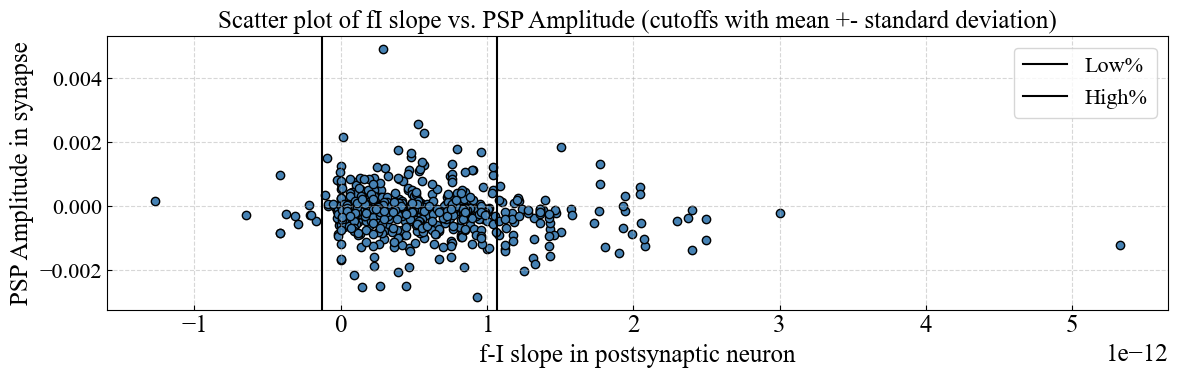

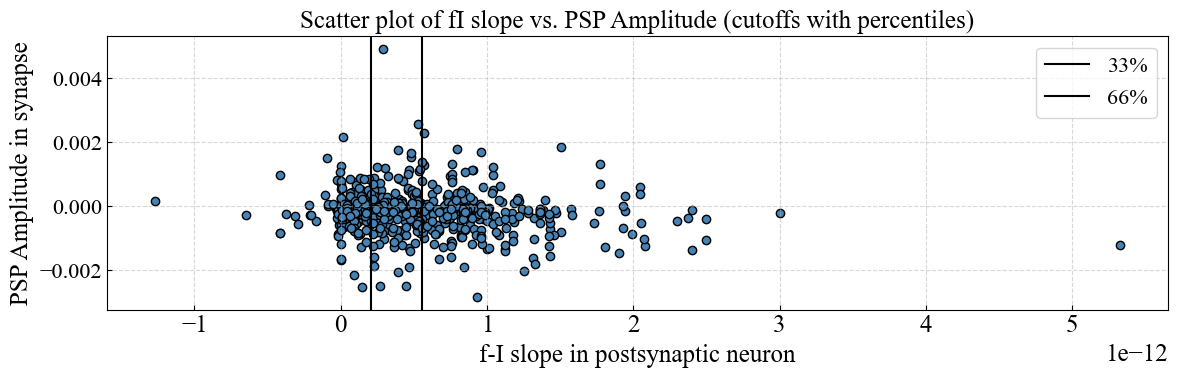

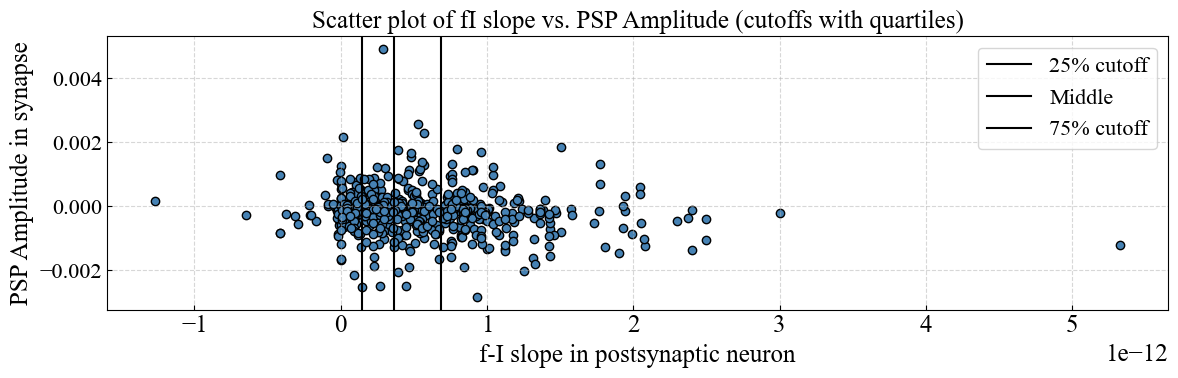

In [19]:
df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()
dfA_nonan = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude

import numpy as np

# View cutoffs

# σ‑based limits 
# pre_mu      = df['pre_mu'].iloc[0]
# pre_sigma   = df['pre_sigma'].iloc[0]
post_mu     = df['post_mu'].iloc[0]
post_sigma  = df['post_sigma'].iloc[0]

# pre_cut_low  = pre_mu - pre_sigma
# pre_cut_high = pre_mu + pre_sigma
post_cut_low = post_mu - post_sigma
post_cut_high = post_mu + post_sigma

# print("Pre‑σ cut‑offs :", pre_cut_low, pre_mu, pre_cut_high)
print("Post‑σ cut‑offs:", post_cut_low, post_mu, post_cut_high)


df_synapses = dfA_nonan[dfA_nonan["has_synapse"]==1]

df_synapses

# print(f"Number of unique synapses: {len(df_synapses['synapse_id'].unique())}")

df_xy = df_synapses[["fi_slope_post", "psp_amplitude"]]

plt.figure(figsize=(12, 4))
plt.scatter(df_xy["fi_slope_post"], df_xy["psp_amplitude"], color="steelblue", edgecolor="k")
plt.title("Scatter plot of fI slope vs. PSP Amplitude (cutoffs with mean +- standard deviation)")
plt.xlabel("f-I slope in postsynaptic neuron")
plt.axvline(post_cut_low, color='black', label="Low%")
plt.axvline(post_cut_high, color='black', label="High%")
# plt.axvline(post_q1, color='purple', label="q1")
# plt.axvline(post_q2, color='purple', label="q2")
# plt.axvline(post_q3, color='purple', label="q3")
plt.ylabel("PSP Amplitude in synapse")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.scatter(df_xy["fi_slope_post"], df_xy["psp_amplitude"], color="steelblue", edgecolor="k")
plt.title("Scatter plot of fI slope vs. PSP Amplitude (cutoffs with percentiles)")
plt.xlabel("f-I slope in postsynaptic neuron")
plt.axvline(post_33, color='black', label="33%")
plt.axvline(post_66, color='black', label="66%")
# plt.axvline(post_q1, color='purple', label="q1")
# plt.axvline(post_q2, color='purple', label="q2")
# plt.axvline(post_q3, color='purple', label="q3")
plt.ylabel("PSP Amplitude in synapse")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.scatter(df_xy["fi_slope_post"], df_xy["psp_amplitude"], color="steelblue", edgecolor="k")
plt.title("Scatter plot of fI slope vs. PSP Amplitude (cutoffs with quartiles)")
plt.xlabel("f-I slope in postsynaptic neuron")
# plt.axvline(post_33, color='black', label="33%")
# plt.axvline(post_66, color='black', label="66%")
plt.axvline(post_q1, color='black', label="25% cutoff")
plt.axvline(post_q2, color='black', label="Middle")
plt.axvline(post_q3, color='black', label="75% cutoff")
plt.ylabel("PSP Amplitude in synapse")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# plt.hist()


[1.1314518997244929e-13, 8.230065275570382e-13, 7.692308149393981e-14, 2e-13, -1.2698412698412691e-14, 5.062499930755573e-13, 6.240000309448212e-14, 4.3474285483161694e-13, -6.942505546770364e-15, 9.062499891607815e-13, -2.1930501930501898e-13, -3.999998735700493e-14, 2.428571353315485e-13, 4.45714243591726e-13, -1.3559321157208228e-14, -1.3559321157208228e-14, 2.428571353315485e-13, 4.45714243591726e-13, -1.9685041005704823e-14, 1.1851430090680786e-12, 1.399999889373778e-13, 1.8999994970251957e-12, 8.688916827967505e-13, 9.285713940055957e-13, 6.728571482132788e-13, 9.285713940055957e-13, -8.648648648648622e-14, -8.648648648648622e-14, 2.702701588109368e-14, 1.0656370656370646e-13, 5.649999656677224e-13, 5.649999656677224e-13, -2.0758367494562238e-13, 0.0, 1.0285714156539152e-13, 4.552422805491578e-13, 6.509530714398713e-13, 7.862572646808148e-13, 6.371428369119826e-13, 2.791116663303136e-13, 4.399999839419386e-13, 4.814285317972421e-13, 7.640001491699337e-13, 2.666666666666668e-13, 1

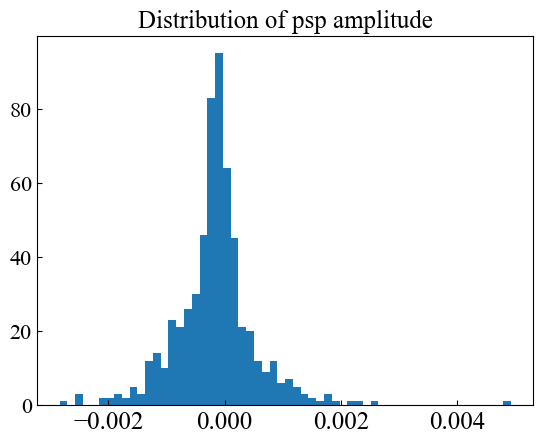

[0.1131451899724493, 0.8230065275570382, 0.07692308149393981, 0.2, -0.012698412698412691, 0.5062499930755573, 0.06240000309448212, 0.43474285483161695, -0.006942505546770364, 0.9062499891607815, -0.219305019305019, -0.03999998735700493, 0.2428571353315485, 0.445714243591726, -0.013559321157208228, -0.013559321157208228, 0.2428571353315485, 0.445714243591726, -0.019685041005704822, 1.1851430090680786, 0.1399999889373778, 1.8999994970251957, 0.8688916827967506, 0.9285713940055957, 0.6728571482132788, 0.9285713940055957, -0.08648648648648623, -0.08648648648648623, 0.027027015881093682, 0.10656370656370646, 0.5649999656677224, 0.5649999656677224, -0.20758367494562238, 0.0, 0.10285714156539152, 0.4552422805491578, 0.6509530714398714, 0.7862572646808148, 0.6371428369119826, 0.2791116663303136, 0.4399999839419386, 0.48142853179724215, 0.7640001491699338, 0.2666666666666668, 1.3133329016792665, 2.076921858026437, 1.0, 1.1230768392374038, 0.5339217556680493, 1.5080003288574577, 1.57142857142857

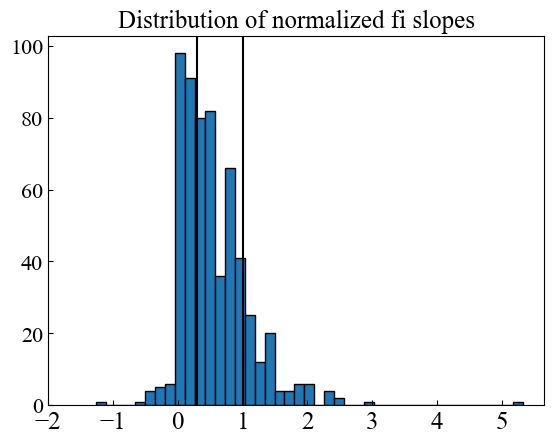

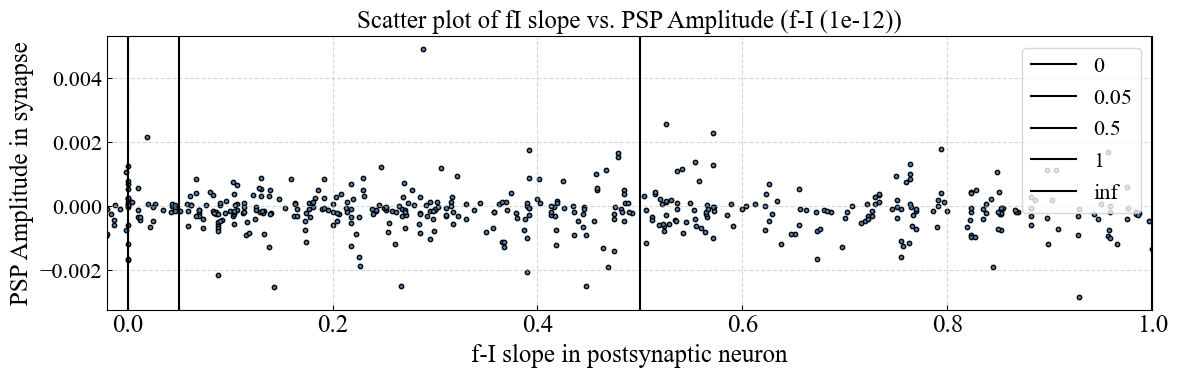

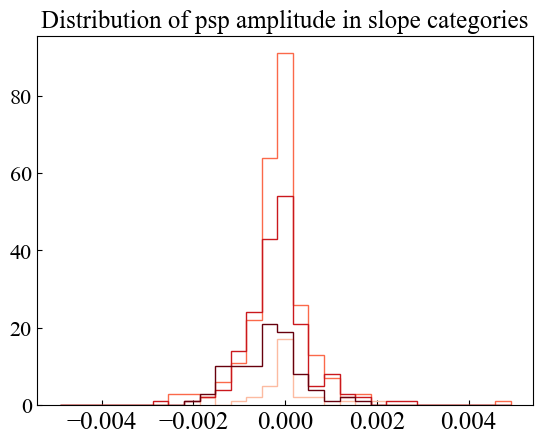

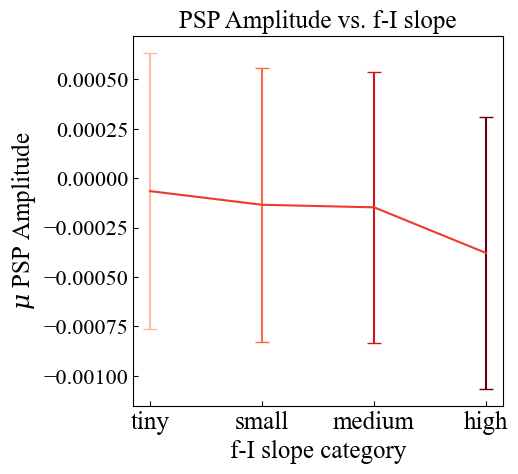

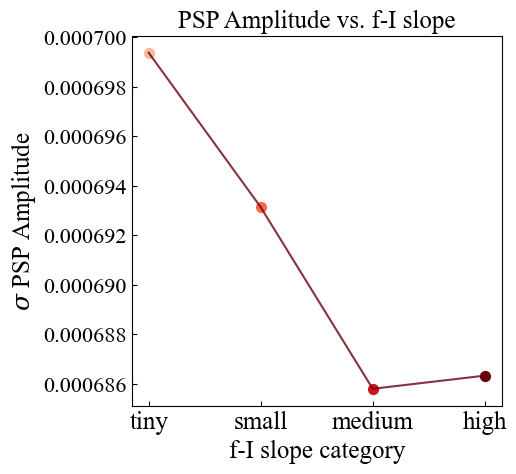

In [132]:
import numpy as np
import matplotlib.pyplot as plt

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))

# Import data
df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()
df = dfA.dropna(subset=["psp_amplitude"])  # exclude those that contain NaN values in PSP amplitude

# First inspection of psp amplitude and fi slope
fi_slopes = df["fi_slope_post"].tolist()
print(fi_slopes)
plt.hist(df["psp_amplitude"], bins='auto')
plt.title("Distribution of psp amplitude")
plt.show()

# plt.hist(df["fi_slope_post"], bins='auto')
# plt.axvline((1*1e-12), color="black")
# plt.title("Distribution of f-I slopes")
# plt.show()


# ------------------------------------------------------------
# Because of how the distribution looked, we had to think about how to bin data
# Lots of data close to zero, more spread after. So Ive tried a smaller bin size close to zero, then wider


df_test = df.copy()


# normalize
df_test["fi_norm"] = df_test["fi_slope_post"] / 1e-12

fi_slopes_normalized = df_test["fi_norm"].tolist()
print(fi_slopes_normalized)

df_test

plt.hist(df_test["fi_norm"], bins='auto', edgecolor='black')
plt.title("Distribution of normalized fi slopes")
plt.xticks(np.arange(-2, 6, 1))
plt.axvline(1, color='black')
plt.axvline(0.3, color='black')
plt.show()

# ------------------------------------------------------------
# Grouping

# Quantiles: Might cause problems since there are way more data in a smaller portion

# df_test["category"] = pd.qcut(df_test["fi_norm"], q=5,     labels=[
#         "very_low",
#         "low",
#         "medium",
#         "high",
#         "very_high"
#     ]
# )

# labels=[
#         "very_low",
#         "low",
#         "medium",
#         "high",
#         "very_high"
#     ]



# Binning: Could be better with small bins where there are many data points, and wider and wider?
bins = [0, 0.05, 0.2, 0.5, 1, 2, np.inf]
bins = [0, 0.33, 0.66, 0.99, 2, np.inf]
labels = [
    "tiny",
    "small",
    "medium",
    "high",
    "very_high",
    "extreme"
]

bins = [0, 0.5, 1, np.inf]
bins = [0, 0.05, 1, np.inf]
labels = [
    "small",
    "medium",
    "high"
]

bins = [0, 0.05, 0.5, 1, np.inf]
labels = [
    "tiny",
    "small",
    "medium",
    "high"
]


# labels = [str(i) for i in range(3)]


df_test["category"] = pd.cut(
    df_test["fi_norm"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

df_test




df_test["category"].value_counts()

# ------------------------------------------------------------
# Plots

color_map_fi = make_color_map(labels, plt.cm.Reds)  # Color map

# Cutoff borders
df_xy = df_test[["fi_norm", "psp_amplitude"]]
plt.figure(figsize=(12, 4))
plt.scatter(df_xy["fi_norm"], df_xy["psp_amplitude"], color="steelblue", s=10, edgecolor="k")
plt.title("Scatter plot of fI slope vs. PSP Amplitude (f-I (1e-12))")
plt.xlabel("f-I slope in postsynaptic neuron")
for b in bins:
    plt.axvline(b, color='black', label=b)
plt.xlim(-0.02, 1)
plt.ylabel("PSP Amplitude in synapse")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



# Histogram across categories
all_vals = df_test["psp_amplitude"].values
max_abs = np.max(np.abs(all_vals))
xmin, xmax = -max_abs, max_abs
bins = np.linspace(xmin, xmax, 30)

fig, ax = plt.subplots(nrows=1, ncols=1)

for l in labels:
    df = df_test[df_test["category"]==l]

    ax.hist(df["psp_amplitude"], bins=bins, histtype='step', color=color_map_fi[l])
ax.set_title("Distribution of psp amplitude in slope categories")
plt.show()


# First and second moment
meanvals = []
stdvals = []
semvals = []

for l in labels:
    df_filtered = df_test[(df_test[f"category"]==l) & (df_test["has_synapse"]==1)]  # this category across experiments

    # Mean of PSP Amplitude across experiments for current 
    mean_psp = df_filtered["psp_amplitude"].mean()  
    meanvals.append(mean_psp)

    # Standard deviation of PSP amplitude across experiments
    std_psp = df_filtered["psp_amplitude"].std()  
    sem_psp = df_filtered["psp_amplitude"].sem()
    stdvals.append(std_psp)
    semvals.append(sem_psp)


# ------------- Mean with errorbars ---------


fig, ax = plt.subplots(
                    nrows=1, 
                    ncols=1, 
                    # figsize=(5, 4)
    )
for l, y, yerr in zip(labels, meanvals, stdvals):
    ax.errorbar(l, y, yerr, capsize=5, color=color_map_fi[l])
    
ax.plot(labels, meanvals, color=color_map_vrest['medium'])
ax.set_ylabel(f"$\mu$ PSP Amplitude")
ax.set_xlabel(f"f-I slope category")
ax.set_title("PSP Amplitude vs. f-I slope")
ax.set_box_aspect(1)
# ax.set_ylim(-0.0020, 0.0020)
# figname = "psp_fi.svg"
# full_path = os.path.join(figure_folder, figname)
# plt.savefig(full_path, format="svg")
plt.show()

# ------------- Standard deviation ---------


fig, ax = plt.subplots(
                    nrows=1, 
                    ncols=1, 
                    # figsize=(5, 4)
    )
ax.plot(labels, stdvals, color=color_map_fi[l], alpha=0.8)
for l, y in zip(labels, stdvals):
    ax.scatter(l, y, s=50, color=color_map_fi[l])
    
ax.set_ylabel(f"$\sigma$ PSP Amplitude")
ax.set_xlabel(f"f-I slope category")
ax.set_title("PSP Amplitude vs. f-I slope")
ax.set_box_aspect(1)
# ax.set_ylim(-0.0020, 0.0020)
# figname = "psp_fi.svg"
# full_path = os.path.join(figure_folder, figname)
# plt.savefig(full_path, format="svg")
plt.show()

# df_test_quantile

## Adjacency matrix

These adjacency matrices marks where synapses occurred if they did. I changed to only include experiments where there was a synapse. Adjacency matrices showing if there was a synapse in an experiment and between which neurons. Change between valid_experiment (to see all) or was_synapse (to see only those with synapses)

Total experiments: 301


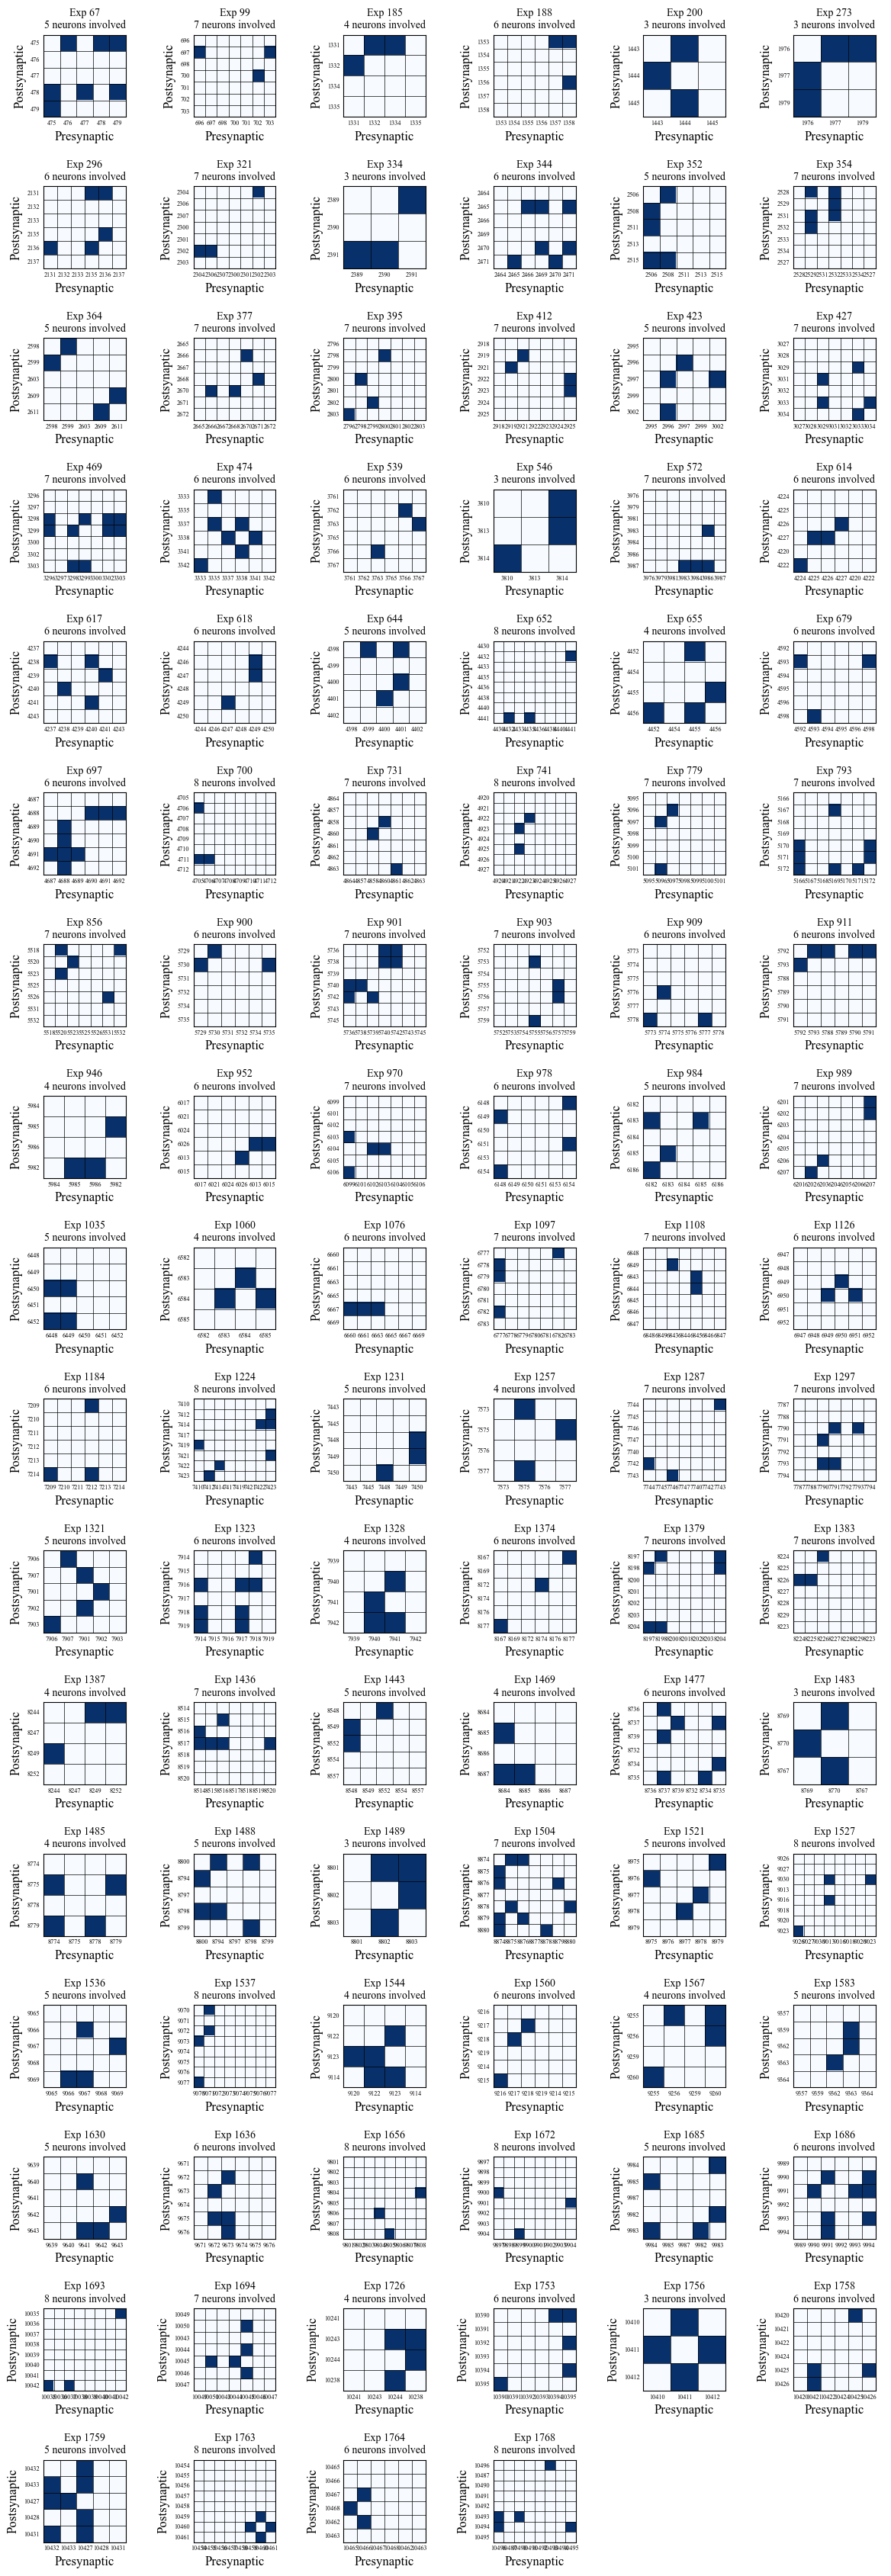

In [ ]:
completed_experiments = []

# -------------------- Specific experiments --------------------
# Query for experiments satisfying a specific criteria, here above a certain number of synapses

query = """ 
            SELECT 
                p.experiment_id,
                COUNT(*) AS total_pairs,
                SUM(p.has_synapse) AS num_synapses,
                COUNT(*) - SUM(p.has_synapse) AS num_no_synapses


            FROM pair p

            INNER JOIN cell pre ON p.pre_cell_id = pre.id
            INNER JOIN cell post ON p.post_cell_id = post.id
            INNER JOIN experiment e ON e.id = p.experiment_id
            INNER JOIN slice s ON e.slice_id = s.id


            WHERE 
                s.species = 'mouse' 
                AND e.target_region = 'VisP' 

                -- No null values in synapse and cell classes
                AND p.has_synapse IS NOT NULL
                AND pre.cell_class IS NOT NULL
                AND post.cell_class IS NOT NULL

                -- We allow mixed cell class in postsynaptic cells, but not in presynaptic cell class
                AND pre.cell_class != 'mixed'
                
            GROUP BY p.experiment_id
            HAVING num_synapses > 1
            ;
        """

experiments = pd.read_sql_query(query, con)

# valid_experiments = df_num_synapses["experiment_id"].tolist()
# was_synapse = df_was_synapse["experiment_id"].unique().tolist()
experiment_ids = experiments["experiment_id"].unique().tolist()

# for exp in valid_experiments:  # uncomment if wall experiments
# for exp in was_synapse:  # only when there was a synapse
for exp in experiment_ids:
    df = df_valid_experiments[(df_valid_experiments["experiment_id"]==exp)]
    pres = df["pre_cell_id"].unique().tolist()
    posts = df["post_cell_id"].unique().tolist()
    total_neurons = list(set(pres) | set(posts))
    n = len(total_neurons)
    possible_synapses = n * (n - 1)

    df_distinct_cells = df[df["pre_cell_id"] != df["post_cell_id"]]  # distinct cells in pre and post
    unique_synapses = df_distinct_cells[['pre_cell_id', 'post_cell_id']].drop_duplicates()  # drop duplicates

    if len(unique_synapses == possible_synapses):
        completed_experiments.append((exp, df, total_neurons))


print(f"Total experiments: {len(completed_experiments)}")
# print(completed_experiments)

# Plot the first 100 valid experiments
n_max = min(100, len(completed_experiments))
n_cols = 6
n_rows = int(np.ceil(n_max / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(2*n_cols, 2*n_rows))
axs = axs.flatten()

flag = 0

rows = []

# Make adjacency matrices
for i, (exp, df, total_neurons) in enumerate(completed_experiments[:n_max]):
    n = len(total_neurons)
    idx_map = {neuron: idx for idx, neuron in enumerate(total_neurons)}  # mapping neuron to index
    adj = np.zeros((n, n))

    synapses = []

    for _, row in df.iterrows():  # iterates through the dataframe
        flag += 1
        pre = row["pre_cell_id"]
        post = row['post_cell_id']
        i_pre = idx_map[pre]
        i_post = idx_map[post]
        # adj[i_pre, i_post] = 1 if row["has_synapse"] == 1 else 0 # ??????? other way around maybe
        adj[i_post, i_pre] = 1 if row["has_synapse"] == 1 else 0  # row is postsynaptic, column is presynaptic


    ax = axs[i]
    im = ax.imshow(adj, cmap="Blues", interpolation='none')

    # (n, n) matrix with cell centers at 0, 1, 2, ..., n-1, and cell borders at -0.5, 0.5, 1.5, ..., n-0.5
    # include minor and major ticks

    neurons = adj.shape[0]

    # Major ticks (centers)
    ax.set_xticks(np.arange(neurons))
    ax.set_yticks(np.arange(neurons))

    # Labels 0 to n-1
    labels = [neuron for neuron, _ in sorted(idx_map.items(), key=lambda x: x[1])]
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)

    # Minor ticks (borders)
    ax.set_xticks(np.arange(-.5, neurons, 1), minor=True)
    ax.set_yticks(np.arange(-.5, neurons, 1), minor=True)

    # Draw grid using minor ticks
    ax.grid(which="minor", color='black', linestyle='-', linewidth=0.5)

    # Hide minor tick marks themselves
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(which="major", bottom=False, left=False)


    ax.set_title(f"Exp {exp}\n{n} neurons involved", fontsize=10)
    ax.set_xlabel("Presynaptic")
    ax.set_ylabel("Postsynaptic")

    ax.set_xlim(-0.5, (neurons - 0.5))
    ax.set_ylim((neurons - 0.5), -0.5) # flipped y axis?



# Hide extra axes
for j in range(i+1, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

# Motif stuff

* Preprocessing to get only relevant data
    * Know when a synapse occurred or not
    * Ensure we inclue only when we could have possibly observed a motif


loop over the list of observed synapses and count:

- **Reciprocal motifs**: if both A→B and B→A exist.
- **Divergent motifs**: one neuron projecting to two.
- **Convergent motifs**: two neurons projecting to the same one.
- **Chain motifs**: A→B→C.

avoid counting the same motif multiple times (e.g., by imposing a condition such as `pre1 < pre2`).


**Motif score**
To quantify how "special" a motif is: z-score **τ**.  
if a given motif is **more or less frequent than expected by chance**, assuming synapses are formed independently.


τ = (p_motif - p²) / σ²

- `p_motif` is the observed frequency of the motif.
- `p` is the overall connection probability.
- `σ² = p(1 - p)` is the variance under a Bernoulli model.

I use the same dataset as in the other cases, i.e. where I can obtain f-I slope for neurons as well.

In [28]:
dfA# DF to CSV
df= pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()

dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,pre_fi_category_pct,post_fi_category_pct,pre_fi_category_quart,post_fi_category_quart,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,high,small,high,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,high,small,high,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,medium,small,medium,small,-0.000314,3391.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,medium,medium,medium,high,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,high,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,small,high,small,high,0.000379,3374.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13


## Frequency of possible motifs and actual motifs

These functions calculate possible motifs. To calculate the possible motifs we take the dataframe where the 'has_synapse' column takes values ​​0 or 1, that is, the measurement was performed and it was determined whether there are ('has_synapse' = 1) or no ('has_synapse' = 0) synapses. The functions are:

```
    possible_rec = count_reciprocal(df)
    possible_div = count_divergent(df)
    possible_con = count_convergent(df)
    possible_chn = count_chain(df)
```

**Then**, we count motifs that are actually present in the data. To do that, we use the subset of connections where synapses were detected ('has_synapse' = 1). We use the same functions as before, i.e.:

```

    df_syn = df[df['has_synapse'] == 1]

    rec_count = count_reciprocal(df_syn)
    div_count = count_divergent(df_syn)
    con_count = count_convergent(df_syn)
    chn_count = count_chain(df_syn)
```

In [15]:
from itertools import combinations
#### Functions to compute motifs
# If has_synapse can be both 0 and 1, it counts possible motifs. If has_synapse can only be 1, it compute motifs observed.

df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()

def count_reciprocal(df):
    ''' 
    Maps whether synapses exist in each direction
     
    '''
    connectivity = set(map(tuple, df[['pre_cell_id','post_cell_id']].values))
    rec = 0

    # Iterate over unordered combinations of pairs of neurons (take combinations, then count pairs of connections only once)

    neurons = df['pre_cell_id'].unique()
    for a, b in combinations(neurons, 2):
        # Does A→B and B→A exist?
        if (a,b) in connectivity and (b,a) in connectivity:
            rec += 1

    return rec


def count_divergent(df):
    ''' 
    For each presynaptic, look at its posts and choose pairs of posts  
    '''
    div = 0
    for pre, subdf in df.groupby('pre_cell_id'):
        posts = subdf['post_cell_id'].unique()
        for post1, post2 in combinations(posts, 2):
            if post1 == post2 or post1 == pre or post2 == pre:
                continue
            div += 1

    return div


def count_convergent(df):
    '''
    For each postsynaptic, look at its pres and choose pairs of pres
    '''
    con = 0
    for post, subdf in df.groupby('post_cell_id'):
        pres = subdf['pre_cell_id'].unique()
        for pre1, pre2 in combinations(pres, 2):
            if pre1 == post or pre2 == post:
                continue
            con += 1

    return con


def count_chain(df):
    '''
    Gamma is an intermediate node: it appears as a post in one connection and a pre in another
    '''
    chn = 0
    for gamma in set(df['pre_cell_id']).intersection(df['post_cell_id']):
        ins  = df[df['post_cell_id']==gamma]  # conexiones pre→gamma
        outs = df[df['pre_cell_id']==gamma]   # conexiones gamma→post
        pres = ins['pre_cell_id'].unique()
        posts = outs['post_cell_id'].unique()
        # Combina cada pre con cada post
        for pre, post in ((p, q) for p in pres for q in posts):
            if pre in (gamma, post) or post in (gamma, pre):
                continue
            chn += 1

    return chn




##### Example

df_valid_experiments = dfA.copy()  # The functions handle unique cell IDs

# df_cleaned = dfA.dropna(subset=["psp_amplitude"])  # Need to decide if we exclude these or not in order to always use exactly the same amount of data across different things

# Count possible motifs - at this point, has_synapse can be either 0 or 1
print("=== Possible motifs ===")
possible_rec = count_reciprocal(df)
possible_div = count_divergent(df)
possible_con = count_convergent(df)
possible_chn = count_chain(df)
possibles = [possible_rec, possible_div, possible_con, possible_chn]
for p in possibles:
    print(p)

# Count actual motifs
print("=== Actual motifs ===")
df_syn = df_valid_experiments[(df_valid_experiments['has_synapse'] == 1)]
rec_count = count_reciprocal(df_syn)
div_count = count_divergent(df_syn)
con_count = count_convergent(df_syn)
chn_count = count_chain(df_syn)
motif_counts = [rec_count, div_count, con_count, chn_count]
for m in motif_counts:
    print(m)


# print(f"Across all experiments there are {count_reciprocal(df_valid_experiments)} reciprocal motifs, {count_divergent(df_valid_experiments)} divergent motifs, {count_convergent(df_valid_experiments)} convergent motifs, {count_chain(df_valid_experiments)} chain motifs.")

# print(f"If we exclude entries that does not measure PSP amplitude, it is across all experiments {count_reciprocal(df_cleaned)} reciprocal motifs, {count_divergent(df_cleaned)} divergent motifs, {count_convergent(df_cleaned)} convergent motifs, {count_chain(df_cleaned)} chain motifs.")



=== Possible motifs ===
3984
10070
10070
20140
=== Actual motifs ===
167
234
221
363


## Compute motif z score

In [16]:
def safe_divide(n, d):
    '''Returns np.nan if the denominator is zero'''
    return n / d if d != 0 else np.nan

def compute_tau(count_motif, count_possible, sigma2, p):
    '''Compute tau'''
    p_motif = safe_divide(count_motif,count_possible)
    return safe_divide((p_motif-p**2),sigma2)

def compute_motifs(df):

    '''
    This function computes the motifs by utilizing the other functions.
    It first get counts of possible motifs.
    It then computes motifs that actually occurred.
    It then computes p (overall connection probability).
    It then calculate sigma^2.
    Finally, it passes these to the function that computes tau (the z score), and return that.
    '''

    # Possible motif count

    possible_rec = count_reciprocal(df)
    possible_div = count_divergent(df)
    possible_con = count_convergent(df)
    possible_chn = count_chain(df)

    # Actual motif count

    df_syn = df[df['has_synapse'] == 1]

    rec_count = count_reciprocal(df_syn)
    div_count = count_divergent(df_syn)
    con_count = count_convergent(df_syn)
    chn_count = count_chain(df_syn)


    # Return nan if no synapses

    if len(df_syn) == 0:
        return (np.nan, np.nan, np.nan, np.nan)
    
    
    # calculate p

    p = len(df_syn) / len(df)  
    
    # calculate sigma^2

    sigma2 = p * (1 - p)  

    # Get tau (z-score)

    tau_rec = compute_tau(rec_count, possible_rec, sigma2, p)
    tau_div = compute_tau(div_count, possible_div, sigma2, p)
    tau_con = compute_tau(con_count, possible_con, sigma2, p)
    tau_chn = compute_tau(chn_count, possible_chn, sigma2, p)
   

    # Return tau (z-score)
    return tau_rec, tau_div, tau_con, tau_chn

df = pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()
tau_rec, tau_div, tau_con, tau_chn = compute_motifs(dfA)

print(f"Tau/z-score is:\n  Reciprocal: {tau_rec}\n  Divergent: {tau_div}\n  Convergent: {tau_con}\n  Chain: {tau_chn}")

Tau/z-score is:
  Reciprocal: 0.3329487992600748
  Divergent: 0.13275627769533999
  Convergent: 0.1189213421614828
  Chain: 0.07688442265476278


## Tau / z-score (motifs) across slope categories

## New

In [17]:
fi_slopes = ["small", "medium", "high"]
# cell_fislope_analyzed = "post"
measuretype = ""
measuretype = "_pct"
measuretype = "_quart"

df= pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
# wDF_2 = pd.read_csv('stats_connectivitymatrix.csv', index_col=0)  # if already saved CSV with index columns

dfA = df.copy()
cats = ["small", "medium", "high"]

experiments = dfA["experiment_id"].unique()
n_experiments = len(experiments)

# Store motifs to compute averages
av_rec=[]
av_div=[]
av_con=[]
av_chn=[]

rows = []

for cat in cats:
    current_fi_slope = dfA[dfA[f"post_fi_category{measuretype}"]==cat]

    if len(current_fi_slope) == 0:
        continue  # skip if there was no data for that category

    elif len(current_fi_slope) > 0:

        # dfM = current_fi_slope[['pre_cell_id', 'post_cell_id']].drop_duplicates()  # remove duplicate connections
        dfM = current_fi_slope.drop_duplicates(
                subset=['pre_cell_id', 'post_cell_id'],
                keep='first'          # keep the first occurrence (default)
        )

        tau_rec, tau_div, tau_con, tau_chn = compute_motifs(dfM)  # Compute tau (z-score)

        # Append all tau/z-score to a list
        # av_rec.append(tau_rec)
        # av_div.append(tau_div)
        # av_con.append(tau_con)
        # av_chn.append(tau_chn)

        row = [cat, tau_rec, tau_div, tau_con, tau_chn]
        rows.append(row)




            

        # for psp in psp_amplitudes:  # If there is more, store one row per
        #     row = [exp, cat, psp]  
        #     rows.append(row)

for r in rows:
    print(r)


columns = ["fi_slope", "tau_rec", "tau_div", "tau_con", "tau_chn"]
dfMotif = pd.DataFrame(rows, columns=columns)



['small', 0.42161613790327995, -0.009470713236056316, 0.12329574495442794, 0.33086101134763024]
['medium', 0.25753815521880324, 0.1318688187345394, 0.07878197584433466, 0.06229630729726217]
['high', 0.4945272513642988, 0.27423262479332194, 0.1213918928377584, 0.1846822991084963]


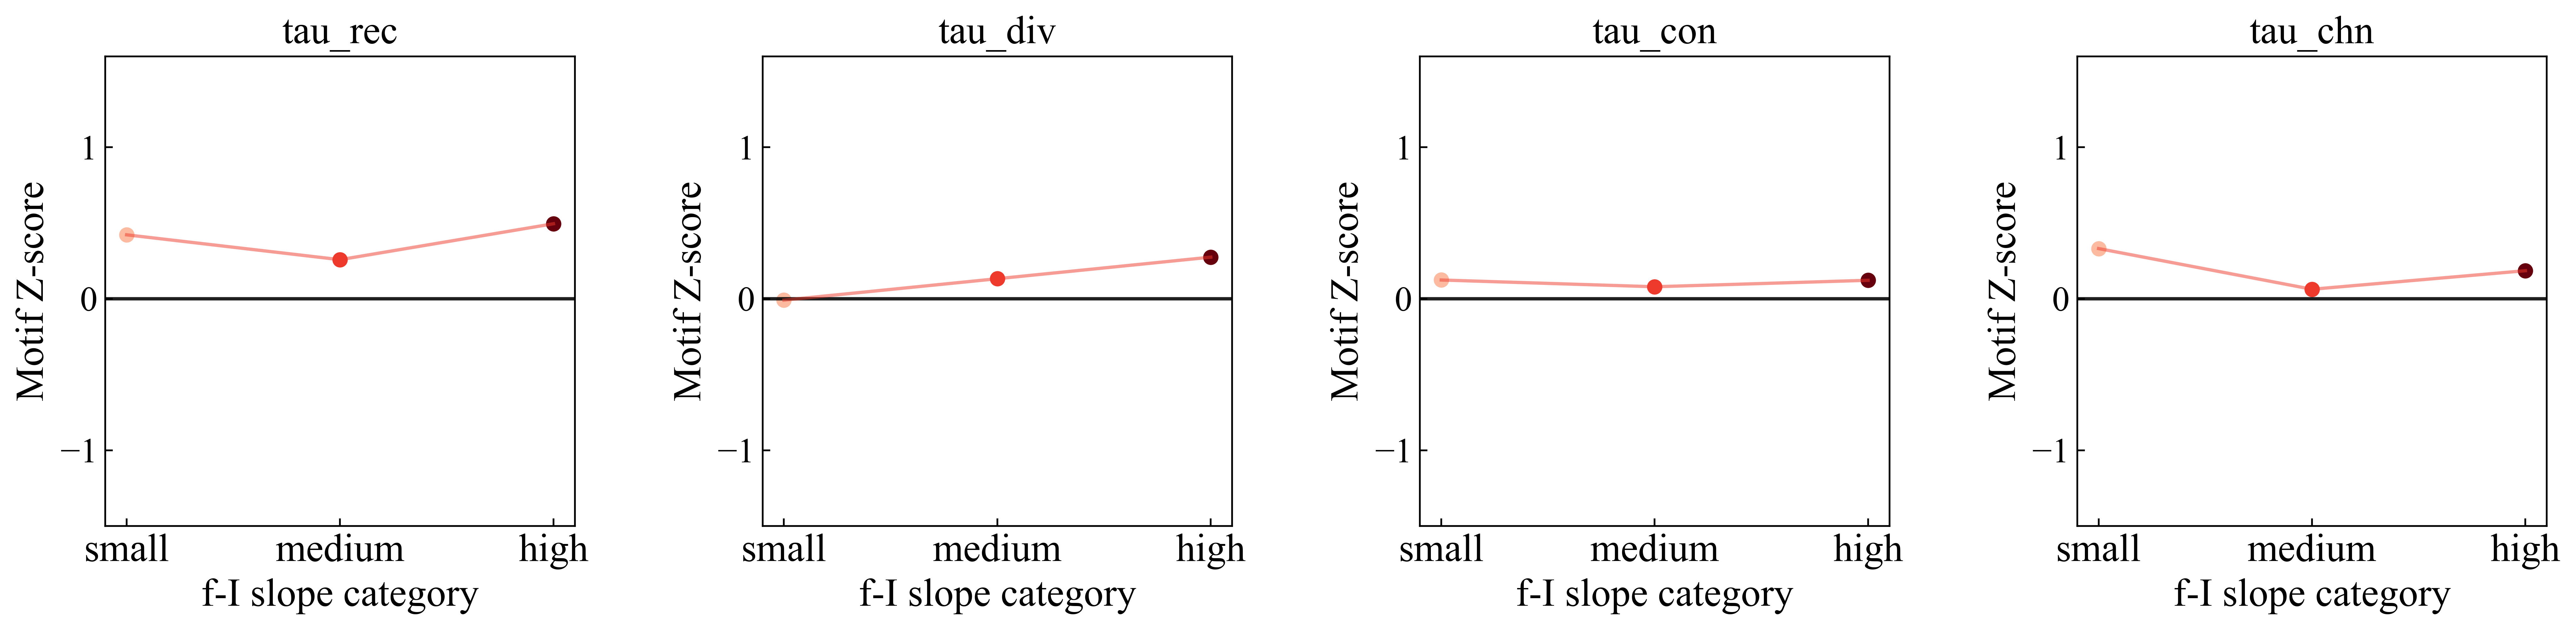

In [18]:
dfMotif
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20, 8))
fig.subplots_adjust(hspace=0.1, wspace=0.4)

taus = ["tau_rec", "tau_div", "tau_con", "tau_chn"]

for i, t in enumerate(taus):

    fi_line = []

    ax = axs[i]

    for fi in fi_slopes:


        df = dfMotif[(dfMotif["fi_slope"]==fi)]
        y = df[t]
        fi_line.append(y)

        # yerr = df[t]

        ax.scatter(fi, y, color=color_map_vrest[fi])
        ax.set_title(f"{t}")
        ax.set_box_aspect(1)
        ax.axhline(0, color='black', alpha=0.5)
        ax.set_ylim(-1.5, 1.6)
        ax.set_xlabel("f-I slope category")
        ax.set_ylabel(f"Motif Z-score")

    ax.plot(fi_slopes, fi_line, color=color_map_vrest["medium"], alpha=0.5)

# plt.suptitle(f"Z-score motif vs. f-I slope ({measuretype})")
plt.show()

In [35]:
dfMotif

,fi_slope,tau_rec,tau_div,tau_con,tau_chn
0,small,0.421616,-0.009471,0.123296,0.330861
1,medium,0.257538,0.131869,0.078782,0.062296
2,high,0.494527,0.274233,0.121392,0.184682


PSP Matrix: original functions and functions that handle NaN

In [ ]:
# Convert the dataframe to a numpy array
psp_matrix_numpy = df_psp_matrix.values

def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.mean(w)
   ww=np.matmul(w,w)
   wtw=np.matmul(w.T,w)
   wwt=np.matmul(w,w.T)
   sigma2=np.trace(wwt)/N
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)
   return tau_rec,tau_div,tau_con,tau_chn


def motifs_zero_filled(w, N):
    """
    Same as original function, but first replace NaNs by 0.
    """
    #  Replace missing entries by 0 (no connection)
    w = np.nan_to_num(w, nan=0.0)

    # Center the matrix using the *overall* mean (now a finite number)
    w = w - np.mean(w)

    # The rest of the algebra is like above
    ww = np.matmul(w, w)
    wtw = np.matmul(w.T, w)
    wwt = np.matmul(w, w.T)

    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn


def motifs_nan_aware(w, N):
    """
    Compute the motif scores while ignoring NaNs when calculating the mean.
    Unmeasured entries are treated as 0 after the centering step.
    """
    # Compute the mean over the *observed* entries only
    w_centered = w - np.nanmean(w)          # nan‑safe mean

    # Replace any still‑nan entries (the ones that were never measured) by 0 so that the matrix algebra can continue.
    w_centered = np.nan_to_num(w_centered, nan=0.0)

    # Continue with the original algebra
    ww = np.matmul(w_centered, w_centered)
    wtw = np.matmul(w_centered.T, w_centered)
    wwt = np.matmul(w_centered, w_centered.T)

    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn

   


# Modify the output print to get values as simple floats
# result = motifs(psp_matrix_numpy, len(all_cells))
# print(f"tau_rec: {result[0].item():.5f}, tau_div: {result[1].item():.5f}, tau_con: {result[2].item():.5f}, tau_chn: {result[3].item():.5f}")

The problem with the code below is that we remove all cases where a synapse occurred. Should not be used to plot motifs, but I keep it for now because I want to later plot some PSP matrices where there actually is values

In [87]:
dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,pre_fi_category_pct,post_fi_category_pct,pre_fi_category_quart,post_fi_category_quart,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,high,small,high,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,high,small,high,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,medium,small,medium,small,-0.000314,3391.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,medium,medium,medium,high,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,high,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,small,high,small,high,0.000379,3374.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13


In [50]:
df_MotifVal

,experiment_id,pop_size,post_cell_id,fi_slope,fi_category,tau_rec,tau_div,tau_con,tau_chn
0,600,3,4140,1.131452e-13,small,0.000000,0.000000,0.000000,-0.500000
1,600,3,4133,8.230065e-13,high,0.000000,0.000000,0.000000,-0.500000
2,610,2,4201,7.692308e-14,small,NaN,NaN,NaN,NaN
3,614,2,4227,2.000000e-13,medium,NaN,NaN,NaN,NaN
4,699,2,4700,-1.269841e-14,neg,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1187,5004,2,24814,1.739197e-13,medium,-0.180961,-0.180961,0.042882,-0.361921
1188,5004,2,24814,1.739197e-13,medium,-0.180961,-0.180961,0.042882,-0.361921
1189,5105,2,24814,9.525691e-14,small,-0.333333,-0.333333,-0.333333,-0.666667
1190,5108,2,24814,6.639170e-14,small,-0.333333,-0.333333,-0.333333,-0.666667


Motifs but according to cell class

In [88]:
dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,pre_fi_category_pct,post_fi_category_pct,pre_fi_category_quart,post_fi_category_quart,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,high,small,high,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,high,small,high,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,medium,small,medium,small,-0.000314,3391.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,medium,medium,medium,high,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,high,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,small,high,small,high,0.000379,3374.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13


In [82]:
import math
import pandas as pd
import numpy as np
# ------------------------------------------------------------


# Get dataframe from main query
df= pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
df_experiments = df.copy()

# Drop NaN PSP Amplitude: TODO maybe not?
# df_experiments = df_experiments.dropna(subset=['psp_amplitude'])

# f-I slope categorization
measuretype = '_pct'

# ------------------------------------------------------------
# Functions computing motifs

def motifs(w,N):
   '''
   Takes the psp matrix, and how many neurons, and perform motif calculations
   
   '''
   w=w-np.mean(w)
   ww=np.matmul(w,w)
   wtw=np.matmul(w.T,w)
   wwt=np.matmul(w,w.T)
   sigma2=np.trace(wwt)/N
   tau_rec=np.trace(ww)
   tau_rec/=sigma2*N
   tau_div=np.sum(wwt)-np.trace(wwt)
   tau_div/=sigma2*N*(N-1)
   tau_con=np.sum(wtw)-np.trace(wtw)
   tau_con/=sigma2*N*(N-1)
   tau_chn=2*(np.sum(ww)-np.trace(ww))
   tau_chn/=sigma2*N*(N-1)
   return tau_rec,tau_div,tau_con,tau_chn


def motifs_zero_filled(w, N):
    """
    Same as original function, but first replace NaNs by 0.
    """
    #  Replace missing entries by 0 (no connection)
    w = np.nan_to_num(w, nan=0.0)

    # Center the matrix using the *overall* mean (now a finite number)
    w = w - np.mean(w)

    # The rest of the algebra is like above
    ww = np.matmul(w, w)
    wtw = np.matmul(w.T, w)
    wwt = np.matmul(w, w.T)

    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn


def motifs_nan_aware(w, N):
    """
    Compute the motif scores while ignoring NaNs when calculating the mean.
    Unmeasured entries are treated as 0 after the centering step.
    """
    # Compute the mean over the *observed* entries only
    w_centered = w - np.nanmean(w)          # nan‑safe mean

    # Replace any still‑nan entries (the ones that were never measured) by 0 so that the matrix algebra can continue.
    w_centered = np.nan_to_num(w_centered, nan=0.0)

    # Continue with the original algebra
    ww = np.matmul(w_centered, w_centered)
    wtw = np.matmul(w_centered.T, w_centered)
    wwt = np.matmul(w_centered, w_centered.T)

    sigma2 = np.trace(wwt) / N

    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn


import numpy as np

def motifs_safe(w: np.ndarray, N: int):
    """
    Compute the four motif scores in a completely safe way.

    `w` may contain NaNs (missing connections).  
    Missing entries are treated as “no connection” (0) after the centering step.  
    If the matrix is completely empty **or** its variance is zero, the function
      returns (nan, nan, nan, nan) instead of raising warnings.

    Returns
    -------
    tau_rec, tau_div, tau_con, tau_chn : float
    """
    # ------------------------------------------------------------------

    # All‑NaN check

    if np.isnan(w).all():
        return (np.nan, np.nan, np.nan, np.nan)

    # ------------------------------------------------------------------

    # NaN‑aware centring (mean of observed entries only)

    w_centered = w - np.nanmean(w)           # nan‑safe mean
    w_centered = np.nan_to_num(w_centered, nan=0.0)   # unobserved → 0

    # ------------------------------------------------------------------

    # Core algebra (identical to the original formulas)
    ww  = w_centered @ w_centered
    wtw = w_centered.T @ w_centered
    wwt = w_centered @ w_centered.T

    sigma2 = np.trace(wwt) / N

    # ------------------------------------------------------------------

    #  Guard against zero variance or a single‑cell experiment
    if sigma2 == 0 or np.isnan(sigma2) or N <= 1:
        # No variability in the connectivity → motifs are undefined
        return (np.nan, np.nan, np.nan, np.nan)

    # ------------------------------------------------------------------

    # Compute the four motif scores (now safe)
    tau_rec = np.trace(ww) / (sigma2 * N)

    tau_div = (np.sum(wwt) - np.trace(wwt)) / (sigma2 * N * (N - 1))

    tau_con = (np.sum(wtw) - np.trace(wtw)) / (sigma2 * N * (N - 1))

    tau_chn = 2 * (np.sum(ww) - np.trace(ww)) / (sigma2 * N * (N - 1))

    return tau_rec, tau_div, tau_con, tau_chn



def is_all_nan(mat: np.ndarray) -> bool:
    """True if the matrix has no finite (non‑NaN, non‑inf) entry."""
    return not np.isfinite(mat).any()

# ------------------------------------------------------------

# Get experiment IDs
valid_experiments = df_experiments["experiment_id"].unique()
n_experiments = len(valid_experiments) 
print(f"Looping through {n_experiments} experiments")

# Containers
exp_gains = {}
exp_motifs = {}
rows_motif = []

empty = 0
rows = []


# ------------------------------------------------------------
# LOOP

if n_experiments == 0: # If there are no experiments, do nothing
    print("No experiments with sufficient data were found.")
else:
    # ------------------------------------------------------------
    # Figure preparation
    # n_cols = int(np.ceil(np.sqrt(n_experiments)))  # Number of columns
    # n_rows = int(np.ceil(n_experiments / n_cols))  # Number of rows
    # fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))  # Determine figure size based on number of subplots
    # axes = axes.flatten()  # Flatten the axes array for easier access

    # ------------------------------------------------------------
    # Loop through each considered experiment
    for i, experiment_id in enumerate(valid_experiments):
        df_exp = df_experiments[df_experiments['experiment_id'] == experiment_id]  # Only data points from this experiment
        psps_nonan = df_exp["psp_amplitude"].count () # counts number of records that are not NaN
        if psps_nonan==0:
            # if no psp amplitude was measured, skip the experiment and increase the empty counter
            empty += 1
            continue  

        # Containers
        pres_fi = []
        posts_fi = []
        posts_fi_category = []

        # Generate PSP matrix for the experiment
        all_cells = np.sort(pd.unique(df_exp[['pre_cell_id', 'post_cell_id']].values.ravel()))  # To get matrix size
        df_psp_matrix = pd.DataFrame(np.nan, index=all_cells, columns=all_cells)  # Initialize empty matrix

        pop_size = len(all_cells)
        for _, row in df_exp.iterrows():  # Iterate through all rows of current experiment
            pre_cell = row['pre_cell_id']  # Pre cell
            post_cell = row['post_cell_id']  # Post cell
            pre_cell_class = row['pre_cell_class']  # 
            post_cell_class = row['post_cell_class']  # 
            psp_value = row['psp_amplitude']  # PSP amplitude

            # ------------------------------------------------------------
            # Store PSP amplitudes in a matrix for all pre and post cells

            # df_psp_matrix.loc[pre_cell, post_cell] = psp_value
            df_psp_matrix.loc[post_cell, pre_cell] = psp_value  # One entry in the matrix


            # ------------------------------------------------------------
            # One row for this postsynaptic cell
            # post_cell_fi = row['fi_slope_post']
            # posts_fi.append(post_cell_fi)

            # post_cell_fi_cat = row[f'post_fi_category{measuretype}']
            # posts_fi_category.append(post_cell_fi_cat)


            rows.append({
                'experiment_id' : experiment_id,
                'pop_size'      : pop_size,                 # will be repeated
                'pre_cell_id' : pre_cell,
                'pre_cell_class' : pre_cell_class,
                'post_cell_id'  : post_cell,
                'post_cell_class': post_cell_class,
                'fi_slope'      : row['fi_slope_post'],
                'fi_category'   : row[f'post_fi_category{measuretype}']
                # the motif scores (added later) will also be repeated
            })

        # ------------------------------------------------------------

        # Motif calculation



        psp_matrix_numpy = df_psp_matrix.values.astype(float)
        # If the whole matrix is NaN we don't plot it
        if is_all_nan(psp_matrix_numpy):
            # if true, there was no connections at all
            tau_rec, tau_div, tau_con, tau_chn = (np.nan, np.nan, np.nan, np.nan)
        else:

            # tau_rec, tau_div, tau_con, tau_chn = motifs_zero_filled(psp_matrix_numpy, len(all_cells))
            # tau_rec, tau_div, tau_con, tau_chn = motifs_nan_aware(psp_matrix_numpy, len(all_cells))
            tau_rec, tau_div, tau_con, tau_chn = motifs_safe(psp_matrix_numpy, len(all_cells))

            

            # Add to all rows belonging to this experiment
            for row in rows[-len(df_exp):]:   # only the rows we just added
                row.update({
                    'tau_rec' : tau_rec,
                    'tau_div' : tau_div,
                    'tau_con' : tau_con,
                    'tau_chn' : tau_chn
                })

        # ------------------------------------------------------------


# ------------------------------------------------------------
# Assemble dataframe

df_all = pd.DataFrame(rows,
                      columns=['experiment_id',
                               'pop_size',
                               'pre_cell_id',
                               'pre_cell_class',
                               'post_cell_id',
                               'post_cell_class',
                               'fi_slope',
                               'fi_category',
                               'tau_rec',
                               'tau_div',
                               'tau_con',
                               'tau_chn'])


# Can print experiment summary by using this (i.e. drop the repeating info per cell)
df_experiment_summary = df_all[['experiment_id','pop_size',
                                'tau_rec','tau_div','tau_con','tau_chn']] \
                        .drop_duplicates().reset_index(drop=True)


df_MotifVal2 = df_all.copy()

Looping through 878 experiments


In [83]:
df_MotifVal2

,experiment_id,pop_size,pre_cell_id,pre_cell_class,post_cell_id,post_cell_class,fi_slope,fi_category,tau_rec,tau_div,tau_con,tau_chn
0,600,4,4133,in,4138,in,1.105000e-12,high,0.0,0.0,0.0,-0.333333
1,600,4,4133,in,4140,ex,1.131452e-13,small,0.0,0.0,0.0,-0.333333
2,600,4,4133,in,4142,in,8.820777e-13,high,0.0,0.0,0.0,-0.333333
3,600,4,4138,in,4133,in,8.230065e-13,high,0.0,0.0,0.0,-0.333333
4,600,4,4138,in,4140,ex,1.131452e-13,small,0.0,0.0,0.0,-0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
3682,5105,2,24781,ex,24778,mixed,8.018796e-13,high,NaN,NaN,NaN,NaN
3683,5108,2,24790,ex,24791,in,4.244768e-13,medium,NaN,NaN,NaN,NaN
3684,5108,2,24791,in,24790,ex,6.639170e-14,small,NaN,NaN,NaN,NaN
3685,5117,2,24813,ex,24814,in,7.336674e-13,high,NaN,NaN,NaN,NaN


In [76]:
df_MotifVal2

motifs = ['tau_rec', 'tau_div',	'tau_con', 'tau_chn']

df_all_nan_motifs = df_MotifVal2[df_MotifVal2[motifs].isna().all(axis=1)]

df_all_nan_motifs
df_MotifVal2
dfMotif = df_MotifVal2.copy()

dfMotif

,experiment_id,pop_size,pre_cell_id,pre_cell_class,post_cell_id,post_cell_class,fi_slope,fi_category,tau_rec,tau_div,tau_con,tau_chn
0,600,4,4133,in,4138,in,1.105000e-12,high,0.0,0.0,0.0,-0.333333
1,600,4,4133,in,4140,ex,1.131452e-13,small,0.0,0.0,0.0,-0.333333
2,600,4,4133,in,4142,in,8.820777e-13,high,0.0,0.0,0.0,-0.333333
3,600,4,4138,in,4133,in,8.230065e-13,high,0.0,0.0,0.0,-0.333333
4,600,4,4138,in,4140,ex,1.131452e-13,small,0.0,0.0,0.0,-0.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
3682,5105,2,24781,ex,24778,mixed,8.018796e-13,high,NaN,NaN,NaN,NaN
3683,5108,2,24790,ex,24791,in,4.244768e-13,medium,NaN,NaN,NaN,NaN
3684,5108,2,24791,in,24790,ex,6.639170e-14,small,NaN,NaN,NaN,NaN
3685,5117,2,24813,ex,24814,in,7.336674e-13,high,NaN,NaN,NaN,NaN


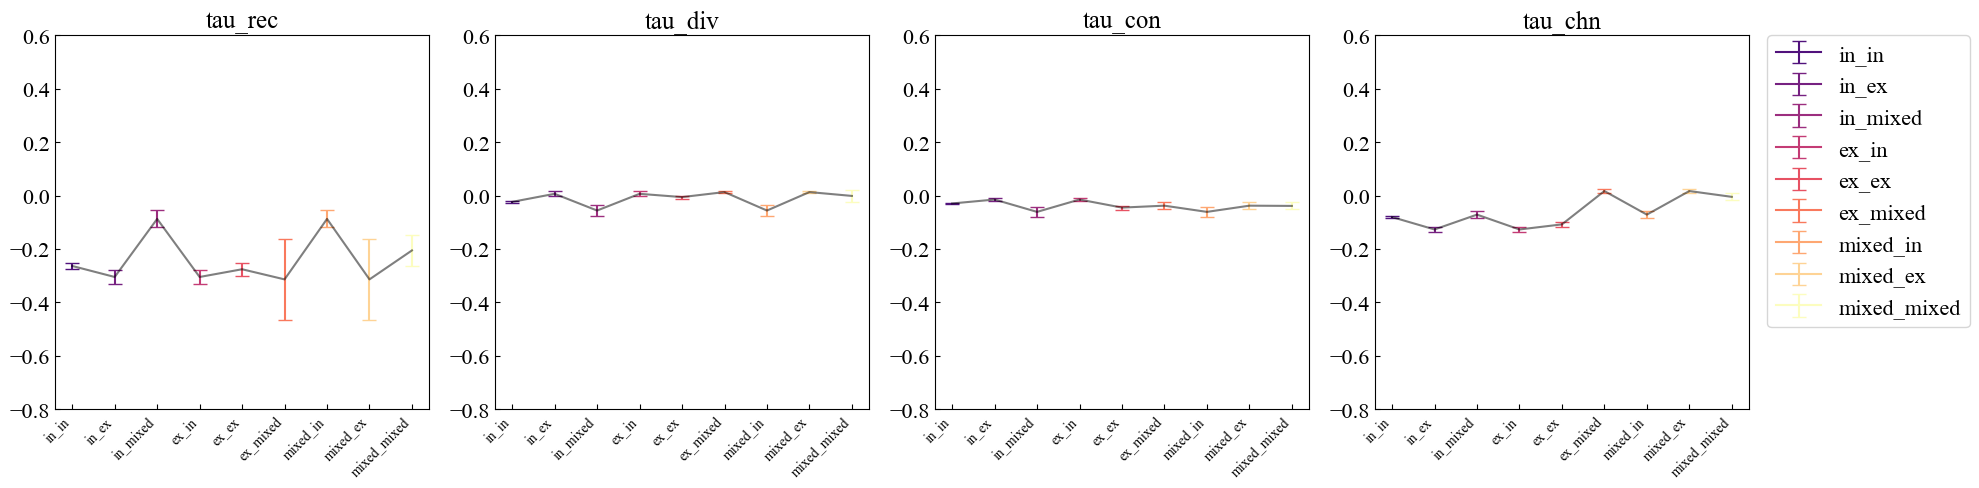

In [78]:

pre_classes = dfMotif['pre_cell_class'].unique()
post_classes = dfMotif['post_cell_class'].unique()
pairs = [f'{pre}_{post}' for pre in pre_classes for post in post_classes]

motifs = ['tau_rec', 'tau_div',	'tau_con', 'tau_chn']
rows = []

all_comb = {}

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))

# Make colors once
color_map_pairs = make_color_map(pairs, plt.cm.magma)  
# color_map_greens = make_color_map(slope, plt.cm.Greens)


fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20,10))
for i, t in enumerate(motifs):
    ax = axs[i]
    meanvals = []
    for pre in pre_classes:
        for post in post_classes:  # Now gets all combinations
            sub = dfMotif[(dfMotif['pre_cell_class'] == pre) & (dfMotif['post_cell_class'] == post)]

            # Mean of current motif across experiments
            mean_motif = sub[t].mean()  
            meanvals.append(mean_motif)

            # Standard deviation of motifs across experiments
            std_motif = sub[t].std() 
            sem_motif = sub[t].sem() 
            stdvals.append(std_motif)

            comb = f"{pre}_{post}"

            # all_comb[comb] = mean_motif

            ax.errorbar(comb, mean_motif, yerr=sem_motif, capsize=5, label=comb, color=color_map_pairs[f"{pre}_{post}"])
            ax.set_box_aspect(1)
            ax.set_title(t)
            ax.set_ylim(-0.80, 0.60)
            ax.set_xticks(np.arange(len(pairs)))
            ax.set_xticklabels(pairs, rotation=45, ha='right', fontsize=10)

    ax.plot(pairs, meanvals, color='black', alpha=0.5)


plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

In [39]:
dfMotif

,experiment_id,fi_slope,tau_rec,tau_div,tau_con,tau_chn
0,600,small,NaN,NaN,-0.500,NaN
1,600,high,-0.125,-0.125,-0.125,-0.125
2,605,small,NaN,NaN,NaN,NaN
3,605,medium,NaN,NaN,NaN,NaN
4,605,high,NaN,NaN,-1.000,NaN
...,...,...,...,...,...,...
1539,5108,medium,NaN,NaN,NaN,NaN
1540,5110,medium,NaN,NaN,NaN,NaN
1541,5110,high,NaN,NaN,NaN,NaN
1542,5117,small,NaN,NaN,NaN,NaN


## Motif value

In [81]:
dfA# DF to CSV
df= pd.read_csv('preprocessed_data_multiplecategories_noneg.csv')  # Has header
dfA = df.copy()

dfA

,experiment_id,pre_cell_id,post_cell_id,has_synapse,pre_cell_class,post_cell_class,fi_slope_pre,fi_slope_post,pre_fi_category,post_fi_category,pre_fi_category_pct,post_fi_category_pct,pre_fi_category_quart,post_fi_category_quart,psp_amplitude,synapse_id,pre_mu,pre_sigma,post_mu,post_sigma
0,600,4133,4138,0,in,in,8.230065e-13,1.105000e-12,medium,high,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
1,600,4133,4140,0,in,ex,8.230065e-13,1.131452e-13,medium,medium,high,small,high,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
2,600,4133,4142,0,in,in,8.230065e-13,8.820777e-13,medium,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
3,600,4138,4133,0,in,in,1.105000e-12,8.230065e-13,high,medium,high,high,high,high,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
4,600,4138,4140,1,in,ex,1.105000e-12,1.131452e-13,high,medium,high,small,high,medium,-0.000204,1895.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,5108,24791,24790,1,in,ex,4.244768e-13,6.639170e-14,medium,medium,medium,small,medium,small,-0.000314,3391.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7974,5110,24798,24799,0,mixed,in,3.932555e-13,5.590663e-13,medium,medium,medium,high,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7975,5110,24799,24798,0,in,mixed,5.590663e-13,3.932555e-13,medium,medium,high,medium,medium,medium,NaN,NaN,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13
7976,5117,24813,24814,1,ex,in,7.079645e-14,7.336674e-13,medium,medium,small,high,small,high,0.000379,3374.0,4.713725e-13,5.964395e-13,4.713725e-13,5.964395e-13


In [27]:
import os


# DF to CSV
df = dfMotif.copy()

# Categorization
measuretype = ""
measuretype = "_quart"
measuretype = "_pct"
cats = ["small", "medium", "high"]
motifs = ['tau_rec', 'tau_div',	'tau_con', 'tau_chn']


experiment_ids = df["experiment_id"].unique()  # Get unique experiment ids
n_experiments = len(experiment_ids)  # how many experiments

rows = []

excluded = 0 # count how many was excluded


stdvals = []

fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20,10))
plt.subplots_adjust(hspace=0.5, wspace=0.5)
for i, t in enumerate(motifs):
    ax = axs[i]
    meanvals = []
    for cat in cats:
        df_filtered = df[(df[f"fi_slope"]==cat)]  # this category across experiments

        # Mean of current motif across experiments
        mean_motif = df_filtered[t].mean()  
        meanvals.append(mean_motif)

        # Standard deviation of motifs across experiments
        std_motif = df_filtered[t].std()
        sem_motif = df_filtered[t].sem()  
        # stdvals.append(std_psp)

        ax.errorbar(cat, mean_motif, yerr=sem_motif, capsize=5, color=color_map_vrest[cat])

    ax.plot(cats, meanvals, color=color_map_vrest['medium'])
    ax.set_title(t)
    ax.set_ylim(-0.8, 0.4)
    ax.set_ylabel("Motif value")
    ax.set_xlabel("f-I Slope")
    ax.set_box_aspect(1)
plt.show()

# Histogram
import numpy as np
import matplotlib.pyplot as plt


# histovals = []

def make_color_map(values, cmap, vmin=0.25, vmax=1.0):
    '''
    Function that takes array of values and make a colormap for them
    '''
    # values_sorted = sorted(values)
    colors = cmap(np.linspace(vmin, vmax, len(values)))
    return dict(zip(values, colors))

# To be given value
motifs = ['tau_rec', 'tau_div',	'tau_con', 'tau_chn']
max_abs = np.nanmax(np.abs(dfMotif[motifs].values))
xmin, xmax = -max_abs, max_abs
bins = np.linspace(xmin, xmax, 40)
# slope_reversed = list(reversed(slope))

# Make colors once
color_map_motifs = make_color_map(motifs, plt.cm.Blues)  
# color_map_greens = make_color_map(slope, plt.cm.Greens)



fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(10,8))
for i, t in enumerate(motifs):
    ax = axs
    motif = df_filtered[t]

    ax.hist(motif, bins=bins, histtype='step', linewidth=1.5, color=color_map_motifs[t], alpha=0.8, label=t)

ax.set_ylabel("Frequency")
ax.set_xlabel("Motif value")
plt.title("Motif Frequency (no categories of f-I slope)")
plt.legend()
plt.show()

NameError: name 'dfMotif' is not defined